<a href="https://colab.research.google.com/github/winterForestStump/FraudDetection/blob/master/bads_final_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FraudDetection**

## Table of contents
1. [Introduction](#introduction)
1. [Imports and data loading](#imports)
3. [Exploratory data analysis](#eda)
4. [Data preprocessing](#preprocessing)
5. [Evaluation metrics](#evaluationfunction)
6. [Experiments with models with default parameters](#imbalanced_data)
6. [Experiments with `class_weight` parameter implementation](#class_weight)
6. [Experiments with cross-validation](#accounting_features)
6. [Experiments with resampling implementation](#resampling)
7. [Experiments with probability calibration curves](#calibration)
8. [Post-tuning decision threshold for cost-sensitive learning](#posttuning)
9. [Conclusion](#conclusion)
9. [Discussion](#discussion)

## Introduction <a name="introduction"></a>

#### Paper

The dataset was created and used by Yang Bao, Bin Ke, Bin Li, Julia Yu, and Jie Zhang (2020) for the Detecting Accounting Fraud in Publicly Traded U.S. Firms Using a Machine Learning Approach. Journal of Accounting Research, 58 (1): 199-235 paper.

Core takeaways of the paper:
* The study constructs a panel of publicly traded U.S. firms from 1991–2008, with fraud cases identified from enforcement actions and matched to non-fraud firm-years. Accounting fraud sample comes from the SEC's AAERs provided by
the University of California-Berkeley Center for Financial Reporting and
Management (CFRM)
* To preserve the intertemporal nature of fraud prediction, the sample is split into a training period (pre-2003) and an out-of-sample test period (2003-2008), with three additional test windows (2003-2005, 2003-2011, 2003-2014) used for robustness checks.
* A minimum 24-month disclosure lag is imposed between the last training observation and each test year to avoid look-ahead bias, reflecting the average time between fraud occurrence and public disclosure.
* Fraud prediction relies on readily available quantitative financial statement data, - only information observable at the prediction date is used.
* Two benchmark models are implemented using the same underlying data:
  * a logistic regression model following Dechow et al. (2011), based on 14 expert-designed financial ratios;
  * an SVM-FK model following Cecchini et al., which transforms the 28 raw variables into a richer set of ratios and ratio changes.
* The proposed approach applies ensemble learning method directly to the raw financial data. RUSBoost model is used, implemented in MATlab code. RUSBoost is a variant of AdaBoost that makes use of random undersampling (RUS) to address the problem of class imbalance learning. It works in much the same way as AdaBoost, except that when training the weak classifier in each iteration, the RUS algorithm uses the full sample of fraudulent firms in the training period and a randomly generated subsample of nonfraudulent firms in the same training period. RUSBoost estimates require selection of the ratio between the number of undersampled majority class observations (i.e., nonfraud) and the number of minority class observations (i.e., fraud). In the paper authors construct RUSBoost model by setting this ratio at 1:1.
* To isolate the source of performance gains, the authors test multiple alternative specifications, including logit models on raw data, ensemble models on financial ratios only, and combined ratio-raw data inputs.
* Model performance is evaluated strictly out-of-sample using NDCG@k, a ranking-based metric that emphasizes correctly identifying the most fraud-prone firms rather than overall classification accuracy.
* Authors find that the ensemble learning model based on the 28 raw financial data items directly outperforms the two benchmark models.

**Erratum:**
August 2022 [article](https://onlinelibrary.wiley.com/doi/10.1111/1475-679X.12454) correcting the paper has been published:
* It was claimed thet coding error in the original study failed to properly recode approximately 10% of "spanning serial fraud" observations in the training data as non-fraud, artificially inflating model performance metrics.
* The erratum provides corrected performance tables (AUC, NDCG@k, frauds identified) for the four test periods after fixing the error.
* Correcting the error does reduce the NDCG@k performance for the RUSBoost model. Consequently, RUSBoost no longer consistently outperforms other models by this metric, except for the earliest test period (2003-2005).
* Performance with different NDCG cutoffs (k) is shown. RUSBoost's advantage in identifying the most fraud cases becomes more pronounced as the cutoff (k) is relaxed from 1% to 5%.

#### Dataset

The file "data_FraudDetection_JAR2020.csv" is the final dataset which contains the fraud labels, feature variables, and related variables (e.g., fyear, gvkey, and p_aaer).

The variable "misstate" is the fraud label (1 denotes fraud, and 0 denotes non-fraud).

The variable "p_aaer" is used for handling the serial fraud issue. We are not interested in this feature during our experiments, so we will disregard it.

The description of the 28 raw accounting variables from Compustat are as follows:
1. act -- Current Assets, Total
2. ap -- Account Payable, Trade
3. at -- Assets, Total
4. ceq -- Common/Ordinary Equity, Total
5. che -- Cash and Short-Term Investments
6. cogs -- Cost of Goods Sold
7. csho -- Common Shares Outstanding
8. dlc -- Debt in Current Liabilities, Total
9. dltis -- Long-Term Debt Issuance
10. dltt -- Long-Term Debt, Total
11. dp -- Depreciation and Amortization
12. ib -- Income Before Extraordinary Items
13. invt -- Inventories, Total
14. ivao -- Investment and Advances, Other
15. ivst -- Short-Term Investments, Total
16. lct -- Current Liabilities, Total
17. lt -- Liabilities, Total
18. ni -- Net Income (Loss)
19. ppegt -- Property, Plant and Equipment, Total
20. pstk -- Preferred/Preference Stock (Capital), Total
21. re -- Retained Earnings
22. rect -- Receivables, Total
23. sale -- Sales/Turnover (Net)
24. sstk -- Sale of Common and Preferred Stock
25. txp -- Income Taxes Payable
26. txt -- Income Taxes, Total
27. xint -- Interest and Related Expense, Total
28. prcc_f -- Price Close, Annual, Fiscal

The description of the 14 financial ratio variables are as follows:
1. dch_wc -- WC accruals
2. ch_rsst -- RSST accruals
3. dch_rec -- Change in receivables
4. dch_inv -- Change in inventory
5. soft_assset -- % Soft assets
6. dpi -- Depreciation index
7. ch_cs -- Change in cash sales
8. ch_cm -- Change in cash margin
9. ch_roa -- Change in return on assets
10. ch_fcf -- Change in free cash flows
11. reoa -- Retained earnings over total assets
12. EBIT -- Earnings before interest and taxes over total assets
13. issue -- Actual issuance
14. bm -- Book-to-market

Total: 42 variables (28 raw accounting + 14 financial ratios)

#### Project goal

To develop and critically evaluate a machine learning framework for the detection of financial misstatements in U.S. public companies: reseacrh technical bias in imbalanced learning, evaluate different metrics for different models and setups.

## Imports and data loading <a name="imports"></a>

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
from sklearn.model_selection import (train_test_split, TunedThresholdClassifierCV, GridSearchCV,
                                     RepeatedStratifiedKFold, StratifiedKFold, cross_validate)
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay, RocCurveDisplay, make_scorer, PrecisionRecallDisplay,
                             brier_score_loss, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import normalize
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import TunedThresholdClassifierCV
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
# 4 meta columns
META_COLS = ["fyear", "gvkey", "misstate"]

# 28 raw accounting variables
RAW_COLS  = ["act","ap","at","ceq","che","cogs","csho","dlc","dltis","dltt",
             "dp","ib","invt","ivao","ivst","lct","lt","ni","ppegt","pstk",
             "re","rect","sale","sstk","txp","txt","xint","prcc_f"]

# 14 financial ratio variables
RATIO_COLS = ["dch_wc","ch_rsst","dch_rec","dch_inv","soft_assets","dpi",
              "ch_cs","ch_cm","ch_roa","ch_fcf","reoa","EBIT","issue","bm"]

# 42 features in total
FEATURE_COLS = RAW_COLS + RATIO_COLS

# Label 'misstate': 0=non-fraud, 1=fraud
LABEL_COL = "misstate"

# path for the dataset
DATA_PATH = ("https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/data_FraudDetection_JAR2020.csv")

data = pd.read_csv(DATA_PATH)
print(f"Loaded: {data.shape[0]:,} rows × {data.shape[1]} columns")

Loaded: 146,045 rows × 46 columns


## Exploratory data analysis <a name="eda"></a>

We will start with the understanding, summarizing and visualizing dataset characteristics.

Firstly, we create a deep copy of the original dataset `df = data.copy()`. This is a safety practice that preserves the integrity of the raw data by creating a separate working DataFrame. Any modifications made during analysis will affect only the copy, allowing us to revert to the original data if needed without reloading it from source.

Then `df.info()` provides a concise summary of the DataFrame: the overall structure of the dataset, the number of non-null values for every feature, and columns' data types.

In [3]:
df = data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146045 entries, 0 to 146044
Data columns (total 46 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   fyear        146045 non-null  int64  
 1   gvkey        146045 non-null  int64  
 2   p_aaer       964 non-null     float64
 3   misstate     146045 non-null  int64  
 4   act          146045 non-null  float64
 5   ap           146045 non-null  float64
 6   at           146045 non-null  float64
 7   ceq          146045 non-null  float64
 8   che          146045 non-null  float64
 9   cogs         146045 non-null  float64
 10  csho         146045 non-null  float64
 11  dlc          146045 non-null  float64
 12  dltis        146045 non-null  float64
 13  dltt         146045 non-null  float64
 14  dp           146045 non-null  float64
 15  ib           146045 non-null  float64
 16  invt         146045 non-null  float64
 17  ivao         146045 non-null  float64
 18  ivst         146045 non-

View first few rows for quick visual inspection:

In [4]:
# transpose to read all the columns
df.head(5).T

,0,1,2,3,4
fyear,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000
gvkey,1009.000000,1011.000000,1017.000000,1021.000000,1028.000000
p_aaer,NaN,NaN,NaN,NaN,NaN
misstate,0.000000,0.000000,0.000000,0.000000,0.000000
act,10.047000,1.247000,55.040000,24.684000,17.325000
ap,3.736000,0.803000,3.601000,3.948000,3.520000
at,32.335000,7.784000,118.120000,34.591000,27.542000
ceq,6.262000,0.667000,44.393000,7.751000,-12.142000
che,0.002000,0.171000,3.132000,0.411000,1.017000
cogs,30.633000,1.125000,107.343000,31.214000,32.662000


* 146045 rows and 46 columns, memory usage of 51.3 MB
* 42 float64 columns with financial metrics and calculated ratios, 4 int64 columns with dentifiers and binary indicators.
* p_aaer consists only 964 non-null values (0.66% complete)

#### Target variable (misstatement classification) distribution

Analysis of the target `misstatemnet` variable distribution. `value_counts()` computes the absolute frequency of each class (0 for non-fraud, 1 for fraud), `
value_counts(normalize=True)` calculates the relative proportions, showing the percentage distribution. For visual representation seaborn's `countplot` is used to create a bar chart of class frequencies.


--- Class distribution ---
           count  proportion
misstate                    
0         145081    0.993399
1            964    0.006601


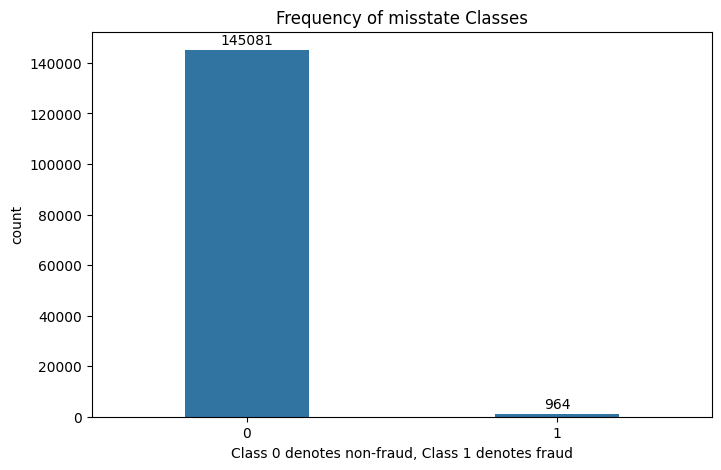

In [5]:
counts = df[LABEL_COL].value_counts()
props  = df[LABEL_COL].value_counts(normalize=True)
print("\n--- Class distribution ---")
print(pd.DataFrame({"count": counts, "proportion": props}))

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='misstate', data=df, width=0.4)
ax.set_xlabel('Class 0 denotes non-fraud, Class 1 denotes fraud')

# text labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 7),
                textcoords = 'offset points')

plt.title('Frequency of misstate Classes')
plt.show()

* The dataset is severely imbalanced: ratio is ~ 150:1 (for every fraud case, there are 150 non-fraud cases). The fraud cases represent 0,6% of the total dataset, which is typical for financial fraud detection.
* Total number of fraud cases is 964, which is better than many real-world scenarios where fraud cases might number in dozens.
* Minority class with less than 1% of the total observations is a challenge. Two primary ways to address it:
- data distribution has to be preserved as it is, because altering the distribution through resampling can lead to probability distortion (artificially balancing a dataset often results in poorly calibrated models that overestimate the likelihood of fraud in a production environment), information loss (under-sampling the majority class risks discarding valuable "normal" patterns that the model needs to distinguish between subtle fraud and legitimate high-value transactions).
- resampoling techniques have to be implemented. When the fraud class is negligible, the gradient descent process may converge on a "trivial" solution where the model achieves a global minimum by predicting the majority class for all instances. Techniques such as SMOTE (Synthetic Minority Over-sampling Technique) are employed to densify the feature space of the minority class, allowing the learner to establish more robust decision boundaries. An alternative to physical resampling is the use of a weighted loss function. By assigning a higher penalty to misclassified minority instances, the optimization process is forced to prioritize the "rare" signal.

We will experiment with implementing different approaches:
* Standard accuracy-based metrics will be misleading (a model predicting "non-fraud" for all cases would achieve 99.34% accuracy), so we can calculate precision, recall and F1-scores.
* May require resampling techniques like SMOTE or class weights during training
* Cross-validation strategies (stratified k-fold)
* Precision-Recall curves will be more informative than ROC curves

#### Feature distribution

The dataset consists of 42 financial features across 146,045 year-company observations. We will perform a statistical analysis of all numerical features.

`df[FEATURE_COLS].describe(exclude='object')` computes descriptive statistics (count, mean, std, min, quartiles, max) for all numerical feature columns, we also add `skew()` to compute the skewness coefficient for each feature, measuring asymmetry in the distribution, and `kurtosis()` for measuring the "tailedness" of the distribution.

In [6]:
# suse only feature columns
data_statistics = df[FEATURE_COLS].describe(exclude='object')
# add skewness
skew = pd.DataFrame(data_statistics.skew(numeric_only=True))
skew = skew.rename(columns={0:'skew'}).T
data_statistics = pd.concat([data_statistics, skew], axis=0)
# add kurtosis
kurtosis = pd.DataFrame(data_statistics.kurtosis(numeric_only=True))
kurtosis = kurtosis.rename(columns={0:'kurtosis'}).T
# concat all together
data_statistics = pd.concat([data_statistics, kurtosis], axis=0)
# transpose the table to read all results
data_statistics.T

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
act,146045.0,737.847759,3744.542368,-0.254000,8.277000,47.501000,249.832000,152629.000000,1.441594,0.750714
ap,146045.0,181.993488,1047.546104,0.000000,1.151000,6.462000,42.259000,39903.000000,2.479200,7.144590
at,146045.0,2374.041576,11957.736980,0.000000,18.281000,105.346000,672.929000,410074.000000,2.289840,6.052667
ceq,146045.0,887.126243,5056.948150,-25560.000000,6.337000,47.308000,271.547000,284434.000000,1.872625,3.665014
che,146045.0,218.657186,1330.490185,-34.000000,1.144000,9.373000,60.286000,85709.000000,1.780318,2.929064
cogs,146045.0,1302.280756,7870.665783,-366.645000,6.795000,53.382000,372.730000,435726.253000,2.338173,6.334087
csho,146045.0,97.004595,540.874888,0.000000,8.796000,22.540000,60.736000,100092.395000,1.626946,1.948922
dlc,146045.0,127.228109,1023.091819,-0.069000,0.008000,1.363000,12.750000,75553.000000,1.915488,3.778377
dltis,146045.0,201.312344,1628.477359,-19.687000,0.000000,0.063000,24.873000,188791.978000,1.530929,1.328227
dltt,146045.0,538.377614,2660.670828,0.000000,0.000000,4.474000,126.212000,120274.000000,1.492562,1.081310


Output analysis:

* Some raw accounting items (e.g. act - total current assets) have negative minimum which is generally cannot be happen -> additional inspection needed.
* `issue` column is a categorical column [0,1] -> should be excluded from the future normalization.
* The raw accounting items (e.g., at - Total Assets, ap - Accounts Payable) exhibit extreme variance in scale (size heterogeneity). For Total Assets (at), the mean (2374) is significantly higher than the median (105), with a maximum value exceeding 410000. This confirms a heavy right-tail distribution ->  row-wise normalization (scaling by firm size).
* The calculated coefficients of skewness and excess kurtosis indicate non-Gaussian distributions across nearly all variables -> robust scaling or non-linear transformations (e.g., log or Box-Cox) are required to stabilize the variance

#### Comparative analysis between fraud vs. non-fraud firms

Now we can perform a stratified comparative analysis. `groupby(LABEL_COL)` splits the data into two cohorts non-fraud (Class 0) and fraud (Class 1) firms, which enables direct comparison of financial profiles between honest and fraudulent companies.

`agg(["mean", "std"])` computes two aggregated statistics for each group: mean (central tendency, showing typical values for each class), and standard deviation (dispersion, indicating variability within each class). `.T` transposes the output for easier class-by-class comparison.

Comparative statistics by class serve multiple critical purposes in fraud detection. It can identify systematic differences between fraudulent and non-fraudulent firms, may reveal which financial metrics are most discriminative for fraud detection.

In [7]:
# Summary statistics (by class)
print(df.groupby(LABEL_COL)[RAW_COLS].agg(["mean", "std"]).round(4).T), print(df.groupby(LABEL_COL)[RATIO_COLS].agg(["mean", "std"]).round(4).T)

misstate              0           1
act    mean    731.0411   1762.2447
       std    3733.4525   5047.0189
ap     mean    179.6261    538.2890
       std    1040.4847   1786.5826
at     mean   2352.8226   5567.4699
       std   11856.3873  22281.6408
ceq    mean    878.4489   2193.0536
       std    4980.2957  11823.3244
che    mean    217.0271    463.9839
       std    1325.1263   1964.0175
cogs   mean   1289.9052   3164.7896
       std    7859.7640   9184.3239
csho   mean     96.3562    194.5921
       std     540.4755    590.1816
dlc    mean    126.3779    255.1799
       std    1023.7257    914.2489
dltis  mean    199.6310    454.3546
       std    1625.8503   1969.3067
dltt   mean    533.3549   1294.2844
       std    2634.1691   5258.4119
dp     mean    112.6204    211.9099
       std     663.6820    826.0636
ib     mean     99.2498     79.1887
       std     916.6018   2066.6633
invt   mean    166.1236    405.6038
       std     924.4060   1246.2656
ivao   mean     93.6300    2

(None, None)

* fraudulent firms appear larger and more active in capital markets (reflected in the issue and total assets (at) variables)
* profitability metrics for fraudulent firms such as ni (Net Income) and ch_fcf (Change in Free Cash Flow) are notably weaker or more volatile.
* divergence between asset growth and cash flow health may serve as a primary signal for the classification models.
* the high intra-class variance suggests that while the means differ, the distributions overlap significantly.

While the statistical differences between classes are significant, I acknowledge a potential detection bias. Because our ground-truth labels are derived from SEC enforcement actions (the dataset is based on AAERs (Accounting and Auditing Enforcement Releases)), our Class 1 observations may be skewed toward larger, more prominent firms that attract greater regulatory oversight. To mitigate the impact of firm size on our classifier, we need to employ size-normalized ratios during the training process.

#### Feature visual comparisons by Class

This code below creates a grid of boxplots to visualize the distribution of all features across fraud and non-fraud classes. `sym=""` suppresses outlier points to focus on the core distribution (quartiles and whiskers).

* Median lines show central tendency differences
* Box widths (IQR) reveal spread/variability
* Whisker lengths indicate the range of "typical" values (excluding outliers)
* Features with extremely long whiskers indicate heavy-tailed distributions
* Overlapping boxes suggest limited standalone predictive power
* Separated boxes indicate potentially useful features
* Different spreads suggest heteroscedasticity (variance differs by class)

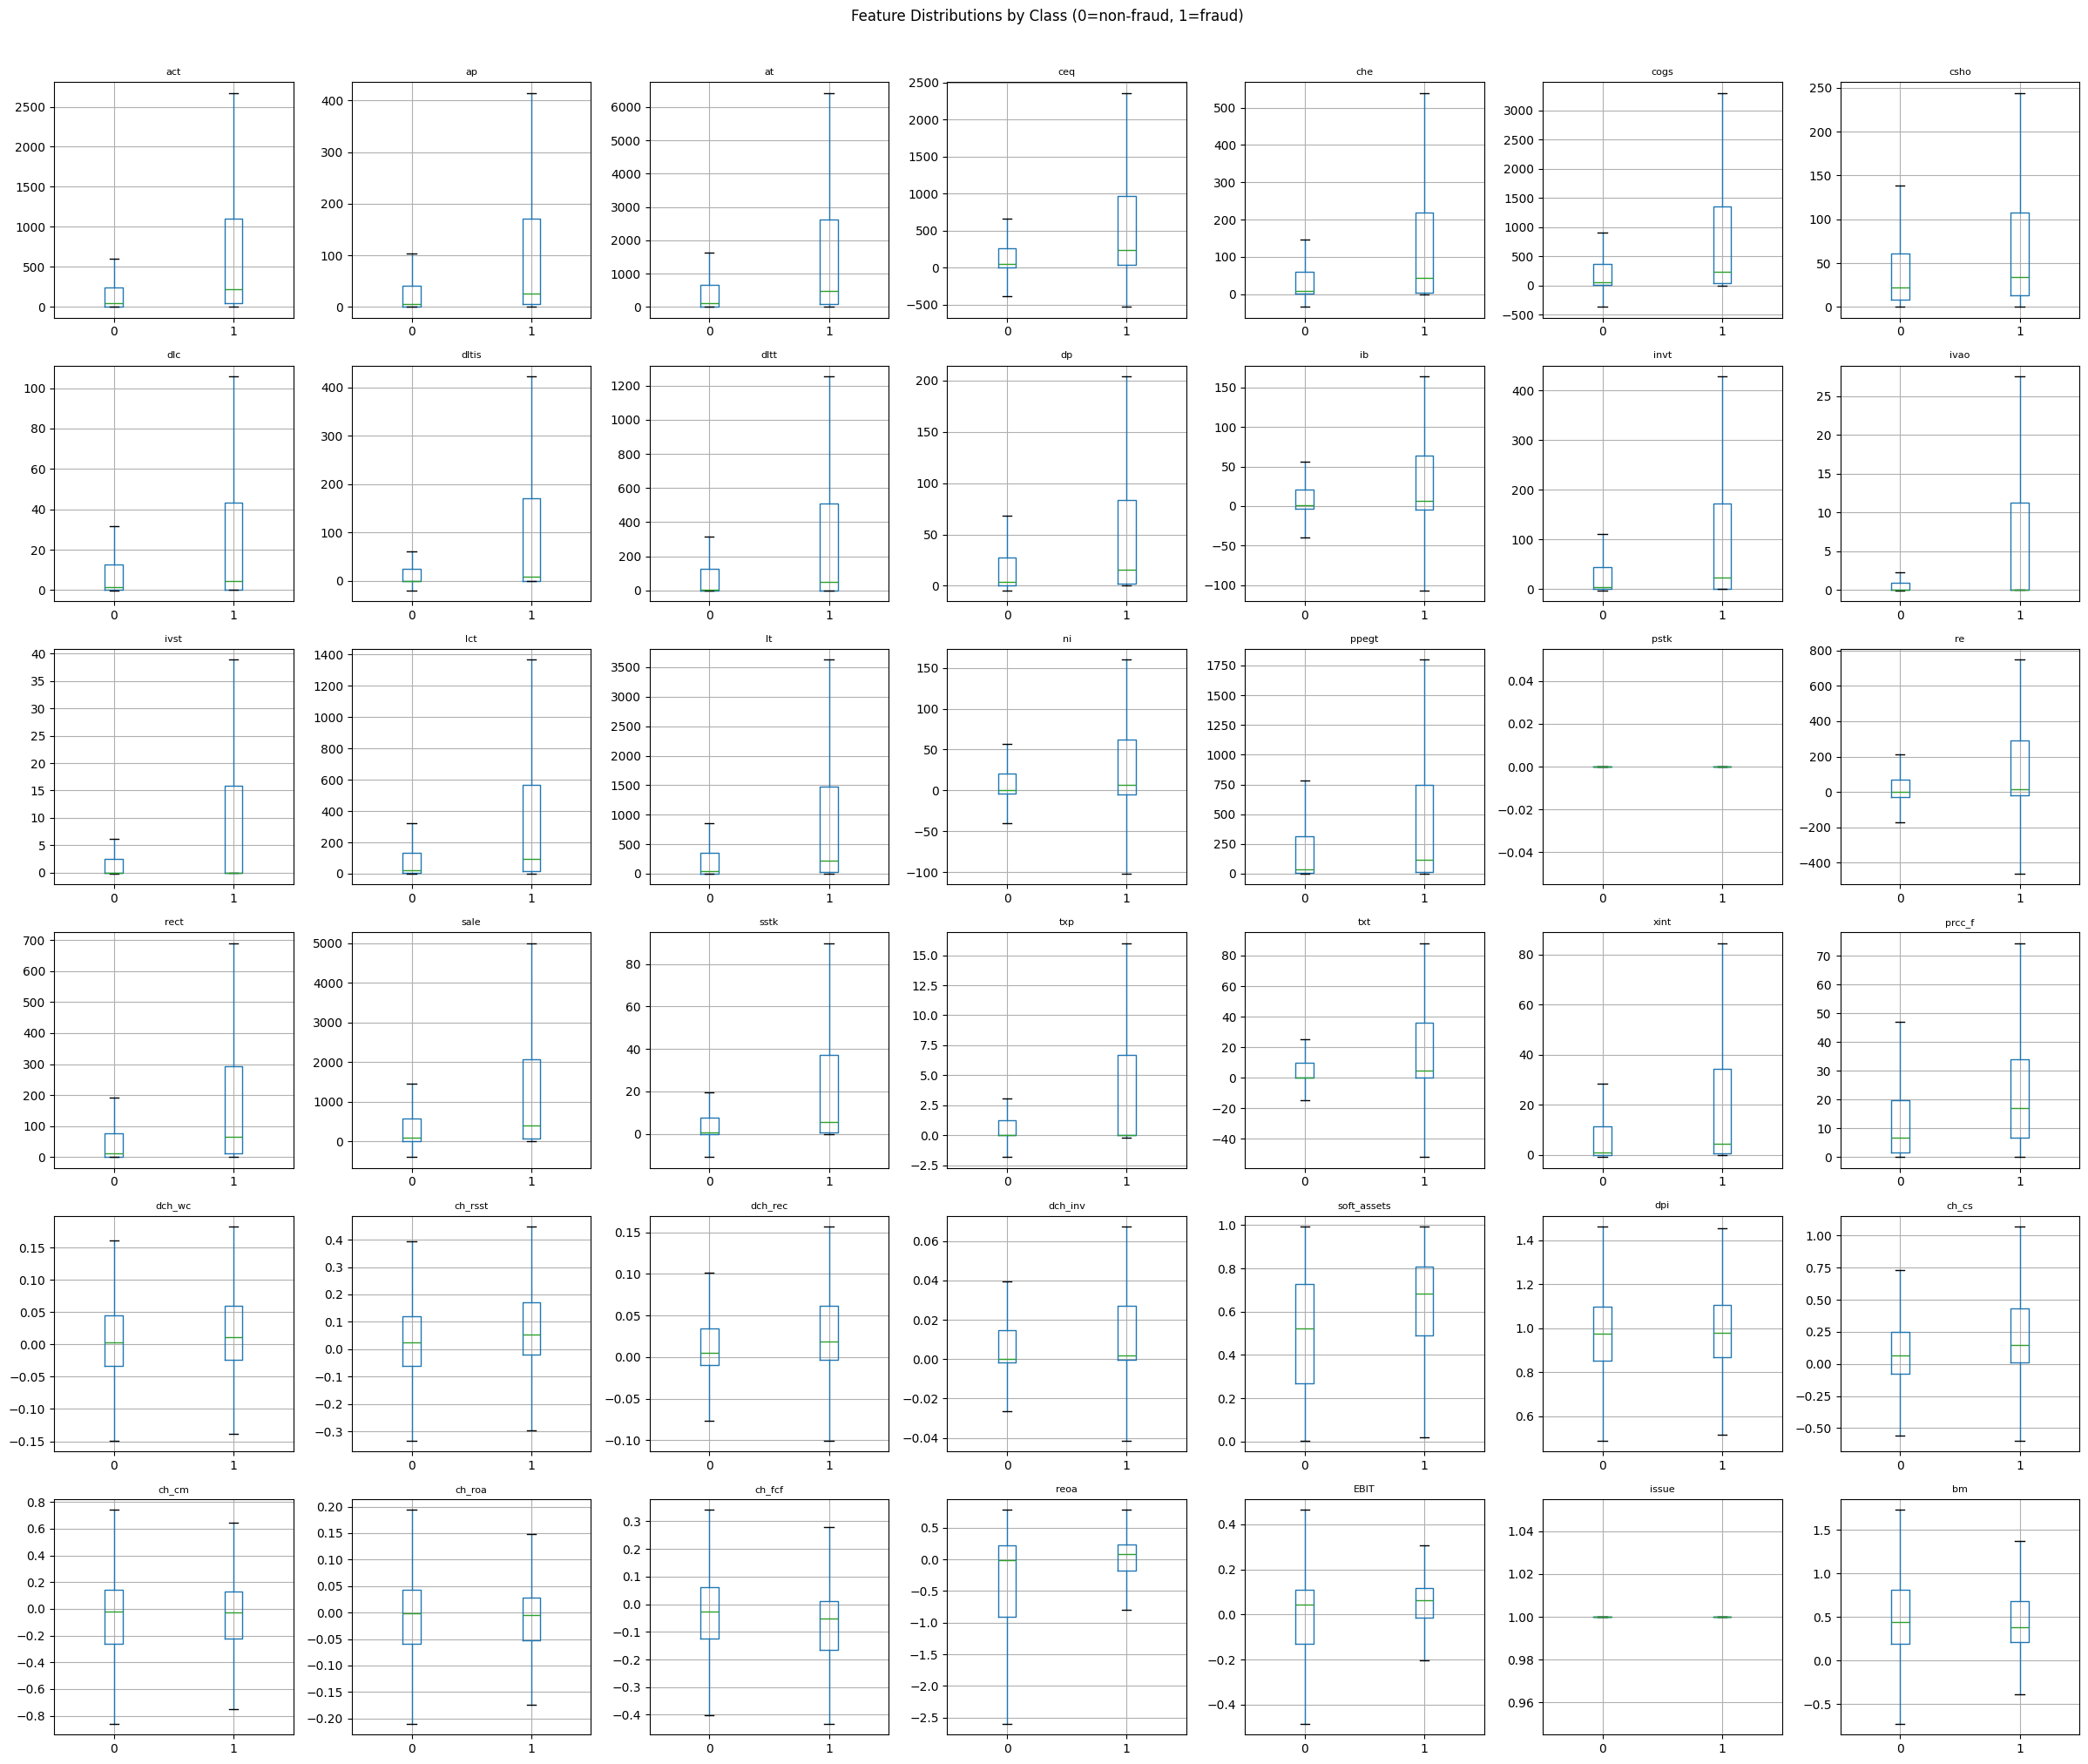

In [8]:
# Feature distributions (box-plots, fraud vs non-fraud)
n_cols = 7
fig, axes = plt.subplots(6, n_cols, figsize=(24, 20))
axes = axes.flatten()
for i, col in enumerate(FEATURE_COLS):
    df.boxplot(column=col, by=LABEL_COL, ax=axes[i], sym="")
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Feature Distributions by Class (0=non-fraud, 1=fraud)", y=1.01)
plt.tight_layout()
plt.show()

* For most features, the median line for fraud firms (class 1) is higher than for non-fraud firms
* This aligns with the earlier finding that fraud firms tend to be larger across most financial metrics
* Some features show minimal median differences, suggesting limited standalone predictive value
* Fraud firms often show wider boxes (larger IQR) -> greater heterogeneity among fraudulent companies
* We observe a systematic shift in the scale of absolute accounting items (e.g., Total Assets, Sales), reinforcing the hypothesis of regulatory detection bias toward larger entities (more in [Discussion](#discussion) section)

#### Fraud (detection) over time

Temporal analysis provides context that cross-sectional statistics cannot capture. `groupby("fyear")` groups the data by fiscal year, `.agg(["sum", "count"])` calculates both the number of fraud cases (sum of binary indicator) and total observations per year

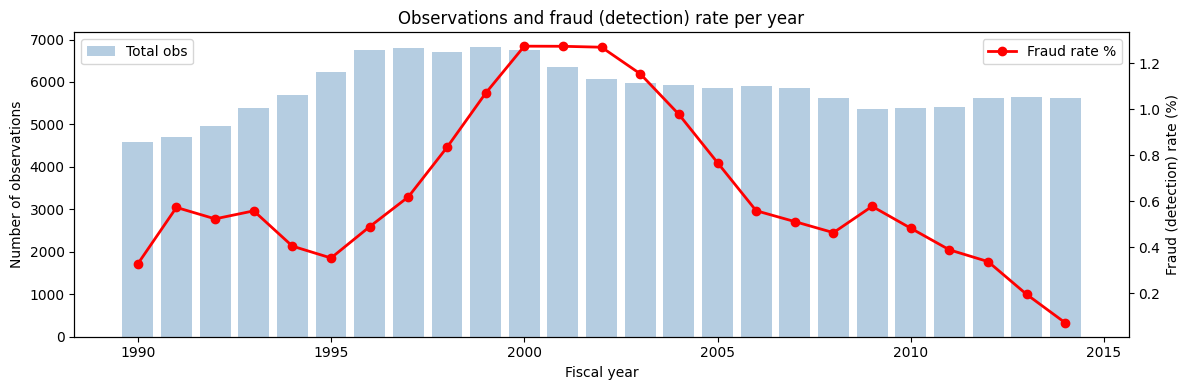

In [9]:
# 2.6 Fraud observations per year
yearly = df.groupby("fyear")[LABEL_COL].agg(["sum", "count"])
yearly.columns = ["fraud_n", "total_n"]
yearly["fraud_rate"] = yearly["fraud_n"] / yearly["total_n"]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.bar(yearly.index, yearly["total_n"], alpha=0.4, label="Total obs", color="steelblue")
ax2.plot(yearly.index, yearly["fraud_rate"] * 100, color="red",
          marker="o", linewidth=2, label="Fraud rate %")
ax1.set_xlabel("Fiscal year")
ax1.set_ylabel("Number of observations")
ax2.set_ylabel("Fraud (detection) rate (%)")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Observations and fraud (detection) rate per year")
plt.tight_layout()
plt.show()

* Fraud rates incresed from ~0.3% in 1995 to nearly 1.2% in 2002-2003. The timing coincides with the Enron, WorldCom, Tyco scandals and subsequent Sarbanes-Oxley Act (July 2002)
* The fraud rate peak around the years 2000-2003, followed by a steady decline, isn't necessarily a reflection of corporate honesty, it may be a reflection of SEC regulatory history
* The high fraud rate here is likely due to the Sarbanes-Oxley Act (SOX) of 2002. The SEC received massive funding increases and a mandate to investigate historical filings.

#### Correlation heat-maps

We can use correlation heatmaps to visualize relationships among raw accounting features (1st plot) and ratio features (2nd plot).

`df[RAW_COLS].corr()` and `df[RATIO_COLS].corr()` compute the Pearson correlation coefficient between all pairs of features. The result is a square matrix where each cell represents the linear relationship between two variables, ranging from -1 (perfect negative) to +1 (perfect positive)

* Accounting identities should produce expected correlations (e.g., assets = liabilities + equity)
* Highly correlated features provide similar information
* Near-zero correlations identify independent information sources

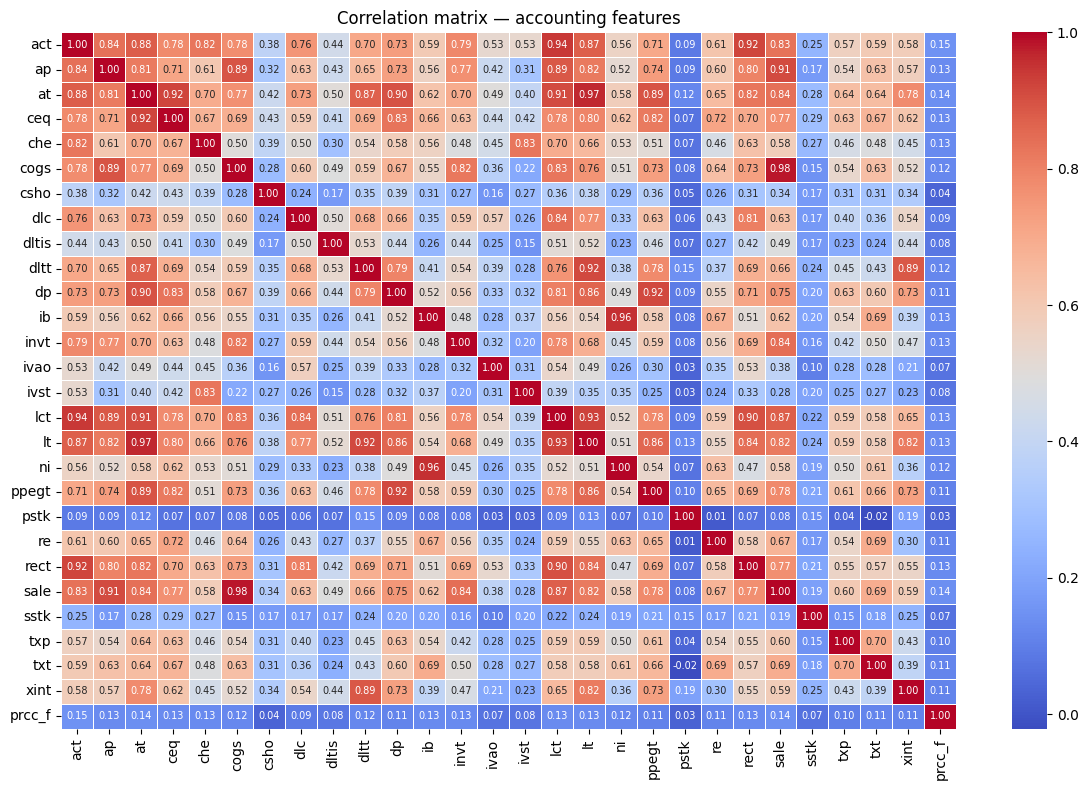

In [10]:
# (accounting features)
corr = df[RAW_COLS].corr()
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation matrix — accounting features")
plt.tight_layout()
plt.show()

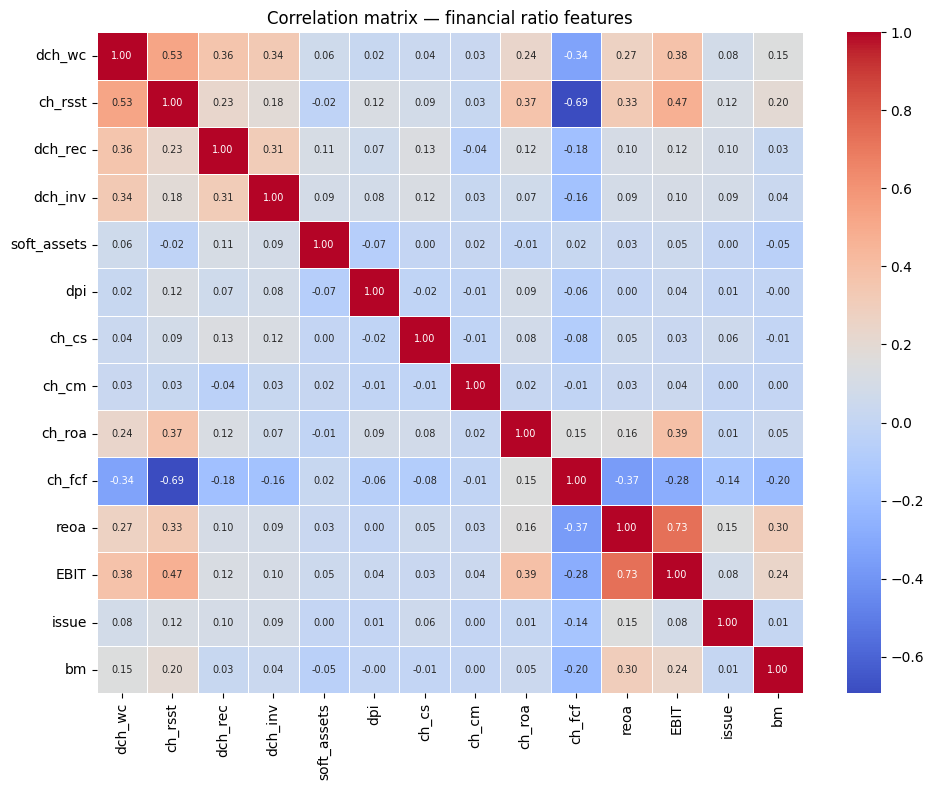

In [11]:
# (ratio features)
corr = df[RATIO_COLS].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation matrix — financial ratio features")
plt.tight_layout()
plt.show()

* Accounting features have groups of correlated and uncorrelated variables. This is logical since balanse sheet data is connected
* Almost all ratio features are uncorrelated. They measure independent aspects (liquidity, profitability, and leverage) which do not move in unison.

#### Missing data analysis

Code performs a two-part analysis of missing data in the feature set.
* quantitative missing value analysis. `df[FEATURE_COLS].isna().sum()` counts missing values per feature column. Filters to include only columns with at least one missing value (missing > 0). Sorts in descending order to highlight features with the most missing data
* visual missing pattern analysis. Creates a binary matrix (isna) where `True` indicates missing values. `sns.heatmap()` visualizes this matrix.

The execution takes significant time - around 10 minutes on google colab.

In [12]:
# 2.3 Missing-value summary
missing = df[FEATURE_COLS].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n--- Missing values (feature columns only) ---")
print(missing.to_string())


--- Missing values (feature columns only) ---
ch_cm          17107
ch_cs          15918
ch_roa         12678
dpi             9228
ch_fcf          5407
ch_rsst         4851
dch_wc          4759
dch_rec         4743
dch_inv         4615
soft_assets      592
reoa             591
EBIT             591
bm                18


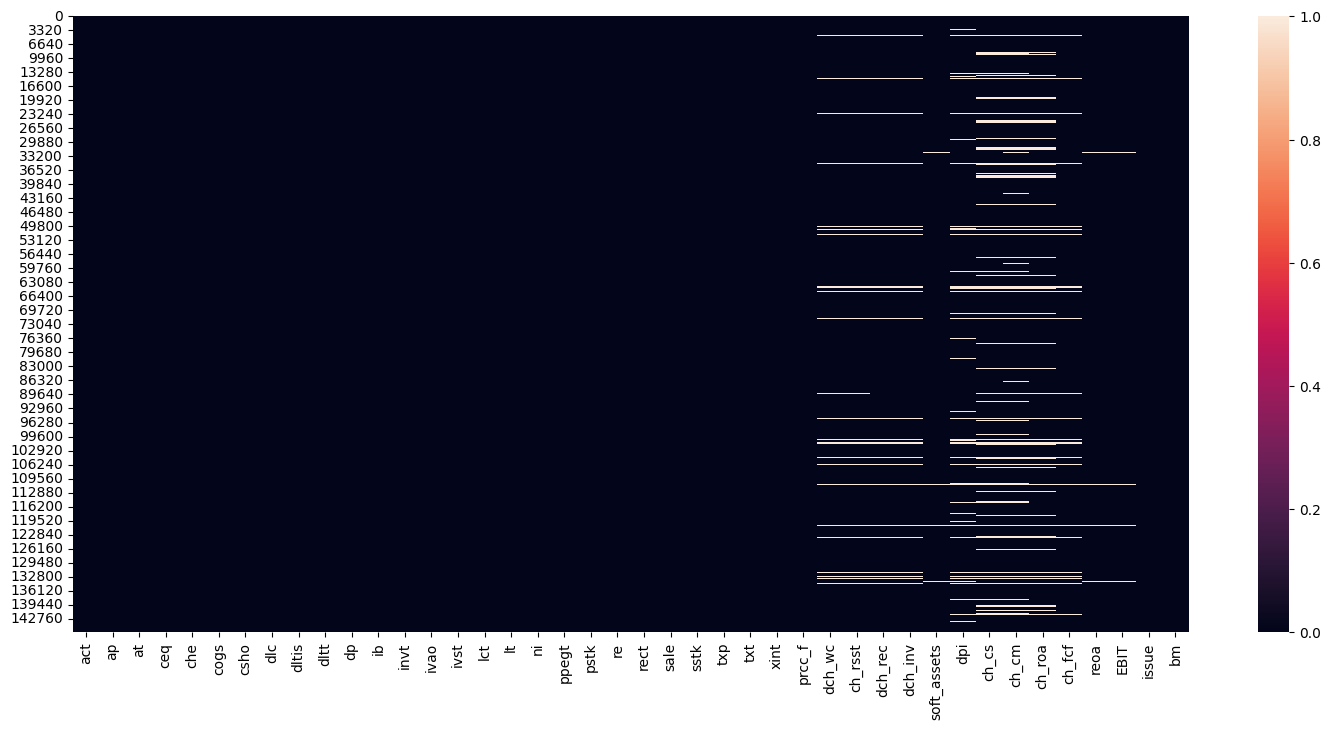

In [13]:
plt.figure(figsize=(18, 8))
isna = df[FEATURE_COLS].isna()
sns.heatmap(isna)
plt.show()

* raw accounting data is free from missing values
* all missing values come from the ratio features

#### Exploring pairwise relationships between features with class-based color coding

This visualization creates multiple scatterplot matrices to explore correlations between all possible pairs of features, with data points colored by their class label (Misstate vs No Misstate).

Can be helpful for visual inspection and identification of potential linear/non-linear relationships between features, discovering class separation patterns, detecting outliers or clusters in the data, understanding feature interactions that might be useful for classification

The code creates all possible combinations of feature pairs using combinations (FEATURE_COLS, 2). Processes feature pairs in batches (80 pairs per figure), each batch becomes a separate figure with its own subplot grid. Each subplot shows a scatterplot of two features. Points are colored by class: 'No Misstate' (0) and 'Misstate' (1).

The code below requires **~1 hour** execution time, which is reasonable given number of pairs ~860, each pair requires rendering a scatterplot and memory constraints in Colab environment. Because of that I run the code localy, saved the plots and added the code as a markdown and final plots as images (so the notebook doesn't have to rerun the task)

From the plots below: There is not a pair of features from which the different classes can be visibly separated.

#### Code for pairwise plotting


```
feature_pairs = list(combinations(FEATURE_COLS, 2))

# grid layout
rows_per_figure = 8
cols_per_figure = 10
plots_per_figure = rows_per_figure * cols_per_figure

# number of figures needed
num_figures = (len(feature_pairs) + plots_per_figure - 1) // plots_per_figure

print(f"Total feature pairs: {len(feature_pairs)}")
print(f"Creating {num_figures} figures with {rows_per_figure}x{cols_per_figure} grid each")

for fig_idx in range(num_figures):
    # Get subset of pairs for this figure
    start_idx = fig_idx * plots_per_figure
    end_idx = min((fig_idx + 1) * plots_per_figure, len(feature_pairs))
    current_pairs = feature_pairs[start_idx:end_idx]

    print(f"Figure {fig_idx + 1}: Plotting pairs {start_idx + 1} to {end_idx}")

    # Create subplots with 8 rows and 10 columns
    fig, axs = plt.subplots(rows_per_figure, cols_per_figure, figsize=(25, 20))
    axs = axs.ravel()  # Flatten for easier indexing

    # At the beginning of your plotting loop:
    with warnings.catch_warnings():
      warnings.simplefilter("ignore", UserWarning)
      for i, pair in enumerate(current_pairs):
          x1, x2 = pair
          ax = axs[i]

          # Create scatterplot
          scatter = sns.scatterplot(
              data=df[FEATURE_COLS],
              x=x1,
              y=x2,
              ax=ax,
              hue=df[LABEL_COL].map({0: 'No Misstate', 1: 'Misstate'}),
              alpha=0.6,
              s=15,  # Smaller point size for dense plots
              linewidth=0
          )

          # Set title (truncate if too long)
          title = f'{x1[:15]} vs {x2[:15]}'
          if len(x1) > 15 or len(x2) > 15:
              title += '...'
          ax.set_title(title, fontsize=8, pad=2)

          # Remove individual legends to reduce clutter
          ax.legend_.remove() if hasattr(ax, 'legend_') else None

          # Adjust tick parameters
          ax.tick_params(axis='x', labelsize=6, rotation=45)  # This handles rotation properly
          ax.tick_params(axis='y', labelsize=6)

          # Rotate x-axis labels for better readability
          ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=6)

      # Hide unused subplots if any
      for i in range(len(current_pairs), len(axs)):
          axs[i].set_visible(False)

      # Add a single legend for the entire figure
      # Get handles and labels from first plot
      if len(current_pairs) > 0:
          handles, labels = axs[0].get_legend_handles_labels()
          fig.legend(handles, labels,
                    loc='lower center',
                    bbox_to_anchor=(0.5, -0.02),
                    ncol=2,
                    fontsize=10,
                    frameon=True,
                    fancybox=True,
                    shadow=True)

      # Adjust layout with more space
      plt.suptitle(f'Feature Pair Scatterplots - Figure {fig_idx + 1} of {num_figures}\n'
                  f'Pairs {start_idx + 1} to {end_idx}',
                  fontsize=14, y=0.995)
      plt.tight_layout(rect=[0, 0.03, 1, 0.98])  # Adjust rect for suptitle and legend

      # Save figure to file
      plt.savefig(f'feature_pairs_figure_{fig_idx + 1}.png',
                  dpi=150,
                  bbox_inches='tight',
                  facecolor='white')

      plt.show()

print(f"Plotting complete! Created {num_figures} figures.")
```



#### Pairwise plots

![1](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/1.png)
![2](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/2.png)
![3](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/3.png)
![4](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/4.png)
![5](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/5.png)
![6](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/6.png)
![7](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/7.png)
![8](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/8.png)
![9](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/9.png)
![10](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/10.png)
![11](https://raw.githubusercontent.com/winterForestStump/FraudDetection/refs/heads/master/11.png)

## Data Preprocessing <a name="preprocessing"></a>

The preprocessing step prepares the dataset for machine learning experiments. Firstly we will  create a working copy to preserve original data

In [14]:
df = data.copy(deep=True)

with `deep=True` (default), a new object is created with a copy of the calling object's data and indices. Modifications to the data or indices of the copy will not be reflected in the original object.

#### Dropping the columns

We can drop `p_aaer` column since we are not interested in so called 'serial fraud' commapnies - commpanies who provide misstated info several years in a row

In [15]:
df.drop(columns=["p_aaer"], inplace=True)

#### Analyzing the minimum values

Some columns have negative minimum values, which in some cases contradict logic and accounting rules. We need to analyze every case and decide if we can delete the instatces.

Check the list of the columns with negative minimums

In [16]:
for col in df.columns:
  if df[col].min() < 0:
    print(f"{col}: {df[col].min()}")

act: -0.254
ceq: -25560.0
che: -34.0
cogs: -366.645
dlc: -0.069
dltis: -19.687
dp: -4.385
ib: -44574.0
invt: -2.683
ivao: -320.866
ivst: -0.225
ni: -98696.0
pstk: -123.0
re: -143336.328
rect: -0.167
sale: -1964.999
sstk: -516.713
txp: -66.0
txt: -34831.0
xint: -0.875
dch_wc: -0.999627561
ch_rsst: -2.072079423
dch_rec: -0.304659498
dch_inv: -0.222021888
ch_cs: -6.484197219
ch_cm: -17.35969922
ch_roa: -1.671565369
bm: -7.034304207
reoa: -89.01324503
EBIT: -7.016393443
ch_fcf: -2.98060139


Now we have to go through all of them and check manually if the negative values are plausible.

`act` - Current Assets, Total. Current assets generally cannot be negative on a balance sheet; if they appear negative, it is usually due to accounting errors, misclassified overdrawn bank accounts, or un-netted contra accounts. We have 8 instances with negative total current assets, all of which have `0` class (no fraud). We can delete all that instances

In [17]:
print(f'Number of negative values: {len(df[df['act']<0])}')
print(f'The misstate distribution in negative values: {df[df['act']<0]['misstate'].value_counts()}')

Number of negative values: 8
The misstate distribution in negative values: misstate
0    8
Name: count, dtype: int64


`ceq` - Common/Ordinary Equity, Total (Shareholder Equity) can be negative. This occurs when a company's total liabilities exceed its total assets, creating a deficit.

`che` - Cash and Short-Term Investments can appear negative, primarily due to bank overdrafts, where a company has spent more money than it holds in its operating accounts. This indicates a negative cash position or an overdrawn bank account, frequently reflecting liquidity challenges or tight working capital management

`cogs` - Cost of Goods Sold (COGS) is generally positive, it can be negative in rare cases, usually indicating an accounting error, massive inventory returns, or prior period adjustments. While theoretically possible due to over-stating ending inventory, a negative COGS typically highlights recording errors rather than actual economic gain. We have 35 instances with negative COGS, all of which have `0` class (no fraud). We can delete all that instances

In [18]:
print(f'Number of negative values: {len(df[df['cogs']<0])}')
print(f'The misstate distribution in negative values: {df[df['cogs']<0]['misstate'].value_counts()}')

Number of negative values: 35
The misstate distribution in negative values: misstate
0    35
Name: count, dtype: int64


`dlc` - Debt in Current Liabilities, Total (short-term debt) can appear as a negative number on a balance sheet, but this is highly unusual and typically indicates an accounting anomaly rather than a true negative obligation. We have 2 instances with negative current debt, all of which have `0` class (no fraud). We can delete all that instances

In [19]:
print(f'Number of negative values: {len(df[df['dlc']<0])}')
print(f'The misstate distribution in negative values: {df[df['dlc']<0]['misstate'].value_counts()}')

Number of negative values: 2
The misstate distribution in negative values: misstate
0    2
Name: count, dtype: int64


`dltis` - Long-Term Debt Issuance can be negative, which indicates that a company is reducing its total long-term debt through repayments, buybacks, or maturities rather than issuing new debt. This means that more debt is being retired than is being newly issued, often termed "net retirement" or "negative net issuance"

`dp` - Depreciation and Amortization can appear as negative values in financial records, usually indicating an increase in an asset's value (appreciation) or specific accounting adjustments like correcting over-depreciation. While rare, negative depreciation represents an asset gaining value rather than losing it.

`ib` - Income Before Extraordinary Items can be negative. This indicates a net loss from a company's core, ongoing operations before accounting for unusual, non-recurring, or infrequent events. It reflects that operating expenses exceeded revenue, a situation often described as a net loss or negative earnings

`invt` - Inventories, Total have to be positive in the Balanse Sheet. Negative values signify a, recording error. We have 1 instance with negative inventory, which has `0` class (no fraud). We can delete it

In [20]:
print(f'Number of negative values: {len(df[df['invt']<0])}')
print(f'The misstate distribution in negative values: {df[df['invt']<0]['misstate'].value_counts()}')

Number of negative values: 1
The misstate distribution in negative values: misstate
0    1
Name: count, dtype: int64


`ivao` - Investment and Advances, Other can be negative, although it is uncommon and usually signals specific, often distressed, financial scenarios.

`ivst` - Short-Term Investments, Total can technically appear as negative in specific, albeit rare, financial contexts, though they are fundamentally classified as current assets

`ni` - Net Income (Loss) can be negative

`pstk` - Preferred/Preference Stock (Capital), Total. Based on standard accounting principles, the Preferred/Preference Stock (Capital), Total account—which represents the par value of preferred shares issued—should not be negative, although the overall shareholder equity or the market value of preferred shares can reflect losses.

`re` - Retained Earnings can be negative, which is referred to as an accumulated deficit, accumulated losses, or retained losses. This occurs when a company's cumulative losses exceed its cumulative profits over time, or when dividend payments exceed net income. Half companies from our dataset have negative retained earnings.

`rect` - Receivables, Total can be negative on a balance sheet, although it is not a "normal" or desirable scenario.

`sale` - Sales/Turnover (Net) can be negative in financial accounting, although it is unusual and indicates that sales returns, allowances, and discounts have exceeded the gross sales amount in a given period.

`sstk` - Sale of Common and Preferred Stock on a cash flow statement could appear negative if a company buys back (repurchases) more shares than it issues, known as treasury stock transactions.

`txp`, `txt` - Income Taxes Payable and Income Taxes, Total can be negative, which typically indicates a tax refund is due or that overpayments/refundable credits exceed the total tax liability.

`xint` - Interest and Related Expense, Total can be negative on a financial statement. While typically representing a cost, a negative value indicates that the company received more interest-related income than it paid out during the period.

All the financial ratios can be negative and doesn't requer individual analyses.

We can delete all instances with negative `act`, `cogs`, `dlc`, `invt`

In [21]:
df.drop(df[df['act']<0].index, inplace=True)
df.drop(df[df['cogs']<0].index, inplace=True)
df.drop(df[df['dlc']<0].index, inplace=True)
df.drop(df[df['invt']<0].index, inplace=True)
df.reset_index(drop=True, inplace=True)

#### Filling missing values

Then we will separate features into two groups: raw financial items and calculated ratios for handling missing values

In [22]:
data_to_norm = df[RAW_COLS].fillna(0)
ratio_data = df[RATIO_COLS].fillna(0)

As EDA previously showed all the missing values are from ratio coefficients. We will fill missing data with 0 (zeros). In financial contexts, missing values often represent zero transactions. It is a simple and interpretable solution.Method works well with L1 normalization (zero values don't affect norm calculation). No data leakage from other samples

We also have to remember about potential issues with this method: zero imputation may introduce bias if missing values are not truly zero. Zeros can distort statistical properties (mean, variance).

We also could've used alternative methods: mean/median imputation (work best with features with normal distribution, preserves central tendency, but reduces variance andd sensitive to outliers), or drop missing values (when more than 5-15% is missing completely, simple, but reduces sample size).

#### Normalization

Next step - features L1 normalization (Unit Norm). Without normalization the model will likely suffer from size bias, where the learner optimizes for large-cap firms and fails to identify fraud patterns in smaller entities.

In [23]:
data_norm = normalize(data_to_norm, norm="l1")  # L1 normalization each row independently

L1 Normalization scales each row to have unit L1 norm (sum of absolute values = 1). It is applied to raw financial items only `[RAW_COLS]`, not ratios.

Why L1? It removes magnitude differences between companies. L1 norm doesn't square values, maintaining zero entries. Normalized values represent proportions of total magnitude. Less sensitive than L2 to extreme values. Converts absolute values to relative proportions, making companies comparable regardless of size.

Why not normalize ratios `[RATIO_COLS]`? Ratios are already scale-invariant (e.g., profit margin, current ratio). Normalizing ratios would destroy their interpretability. Ratios have meaningful ranges (e.g., 0-1, 0-100%)

Again, we've chosen L1 but there are also other alternatives: L2 Normalization, Min-Max scaling, Robust scaling, Quantile transformation (non-linear mapping)

Reconstructing the dataset to preserve column names after normalization and maintain original column order

In [24]:
data_norm = pd.DataFrame(data_norm, columns=data_to_norm.columns)
data_norm = pd.concat([df[META_COLS], data_norm, ratio_data], axis=1)

Metadata (identifiers, dates) shouldn't be normalized. Ratios kept separate as they don't need normalization. Concat with `axis=1` joins horizontally, preserving alignment

## Evaluation metrics <a name="evaluationfunction"></a>

Very high imbalnce in class distrtibution gives us  99,8% (regular, naive) accuracy score before implementing any model - just predicting all instances as not misstated. Obviously, this approach is not usefull. We cann't use accuracy score as a metric with imbalanced dataset - it will be high and misleading.

For the purpose of this notebook experiments we will use the following evaluation metrics:

* Confusion (error) matrix
* ROC-AUC score
* ROC (receiver operating characteristic) curve
* True negative rate (Specificity) = TN / (TN + FP)
* True positive rate (Recall/ Sensitivity) = TP / (TP + FN)
* Precision = TP / (TP + FP)
* F1-score = (2 x Precision x Recall) / (Precision + Recall)

Researchers of the imbalanced data classification also can add to the evaluation stack: Precision@k and Recall@k (focusing on the top k results), NDCG@k (Normalized Discounted Cumulative Gain at top-k items) and many others depending on the research goal, but they are out of our scope for now

In [25]:
def calculate_metrics(y_true, y_pred, y_prob):
    """
    Calculate confusion matrix, ROC curve, true negative rate, recall (TPR), precision, and F-measure.
    """
    # confusion (error) matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    # true negative rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    # true positive rate
    recall = recall_score(y_true, y_pred, zero_division=0)
    # precision
    precision = precision_score(y_true, y_pred, zero_division=0)
    # F-measure (F1-score)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # ROC-related metrics
    fpr, tpr_roc, thresholds = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    # Create side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion Matrix on the left
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=['0 - not misstate', '1- misstate'], ax=ax1, colorbar=True)
    ax1.set_title('Confusion Matrix')

    # ROC Curve on the right
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax2, name=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_title('Receiver Operating Characteristic (ROC) Curve')

    plt.tight_layout()
    plt.show()

    # Create results dictionary
    results_dict = {'Metric': ['Specificity', 'Recall/Sensitivity', 'Precision', 'F1-Score', 'ROC AUC'],
                    'Value': [f'{specificity:.4f}', f'{recall:.4f}', f'{precision:.4f}', f'{f1:.4f}',f'{roc_auc:.4f}']}
    df_results = pd.DataFrame(results_dict)

    return df_results

## Experiments with models with default parameters <a name="imbalanced_data"></a>

In this stage of the research, we establish a baseline performance using a "naive" experimental setup. This serves as a critical benchmark to demonstrate the difficulty of the fraud detection task and the necessity of more advanced techniques.

#### Experimental setup of the naive baseline

We evaluate four diverse classification algorithms using their default hyperparameters on the raw, imbalanced dataset. To ensure a fair assessment of "out-of-the-box" performance, we utilize:
* all features, 42 accounting items and financial ratios.
* no resampling (oversampling/undersampling) or class-weight is applied, preserving the natural 0.6% fraud rate.
* a standard 80/20 train-test split with shuffling enabled (this approach is not robust, more in [Discussion](#discussion1) section)

The objective is to observe how standard loss functions behave when one class (non-fraud) constitutes over 99% of the observations.

In [26]:
y = data_norm[LABEL_COL]
X = data_norm[FEATURE_COLS]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                  test_size=0.2,
                                                  random_state=42,
                                                  shuffle=True)

print(f'Size of training set: {X_train.shape[0], y_train.shape[0]}\n')
print(f'Size of test set: {X_test.shape[0], y_test.shape[0]}\n')

print(f'Train set structure: 0 - no misstate, 1- misstate:\n {y_train.value_counts()}\n')
print(f'Test set structure: 0 - no misstate, 1- misstate:\n {y_test.value_counts()}')

Size of training set: (116799, 116799)

Size of test set: (29200, 29200)

Train set structure: 0 - no misstate, 1- misstate:
 misstate
0    116018
1       781
Name: count, dtype: int64

Test set structure: 0 - no misstate, 1- misstate:
 misstate
0    29017
1      183
Name: count, dtype: int64


For our baseline and subsequent experiments, I selected three models that represent distinct approaches to supervised learning. This allows us to evaluate how different algorithmic structures (linear, hierarchical, and ensemble-based) handle the classification task.

#### LogisticRegression

Logistic Regression serves as the fundamental parametric baseline in accounting research (almost every researh paper contains LR results). Its primary advantage is simplicity, interpretability, as it provides a clear coefficient for each financial ratio, allowing for a direct assessment of which accounting items correlate with fraud (`sklearn` library doesn't provide coefficients though, since it's main purpose is making preddictions, for LR coefficients use `statsmodels` package). Since many financial ratios (e.g., Soft Assets to Total Assets) are expected to have a monotonic relationship with fraud risk, a linear probability model provides a starting point for evaluating the predictive power of the feature set.

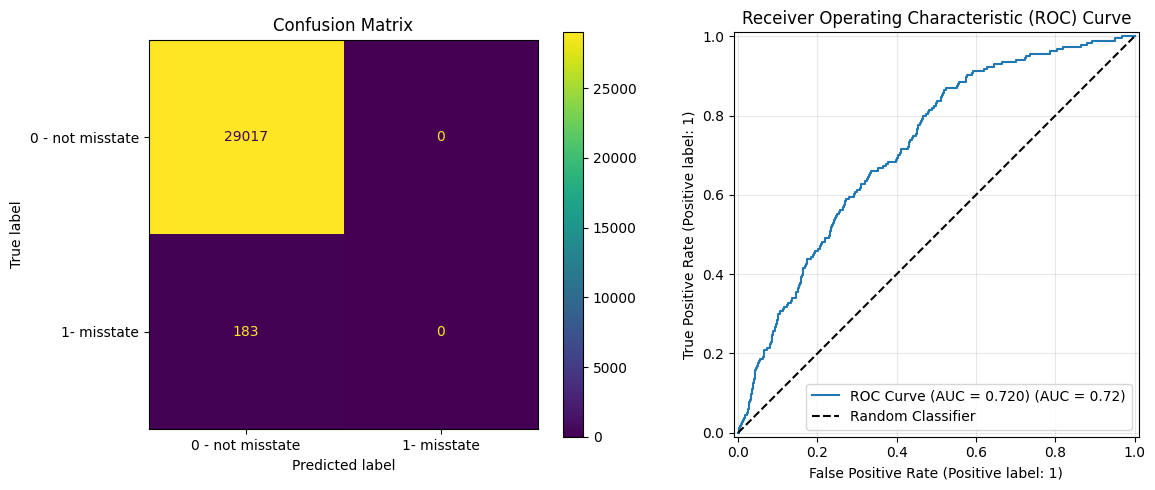

,Metric,Value
0,Specificity,1.0000
1,Recall/Sensitivity,0.0000
2,Precision,0.0000
3,F1-Score,0.0000
4,ROC AUC,0.7200


In [27]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
dec_values = clf.predict_proba(X_test)[:, 1]
calculate_metrics(y_test, pred, dec_values)

Well... at least ROC AUC is 0.72, we may think. But, this is a good example of misleading metrics - with zero true positives we have high ROC AUC due to huge number of true negatives (majority class)

#### Decision Tree

Decision Trees are non-parametric models that do not assume a linear relationship between features. They are naturally adept at capturing threshold-based triggers, for instance, a specific level of change in some accounting item that, once crossed, indicates a significantly higher risk of fraud. Financial auditing often involves a series of "if-then" rules (e.g., "if FCF is negative AND revenue growth is high"). Decision Trees mimic this human-like decision logic, making them useful for discovering complex interactions between accounting variables that a linear model might miss.

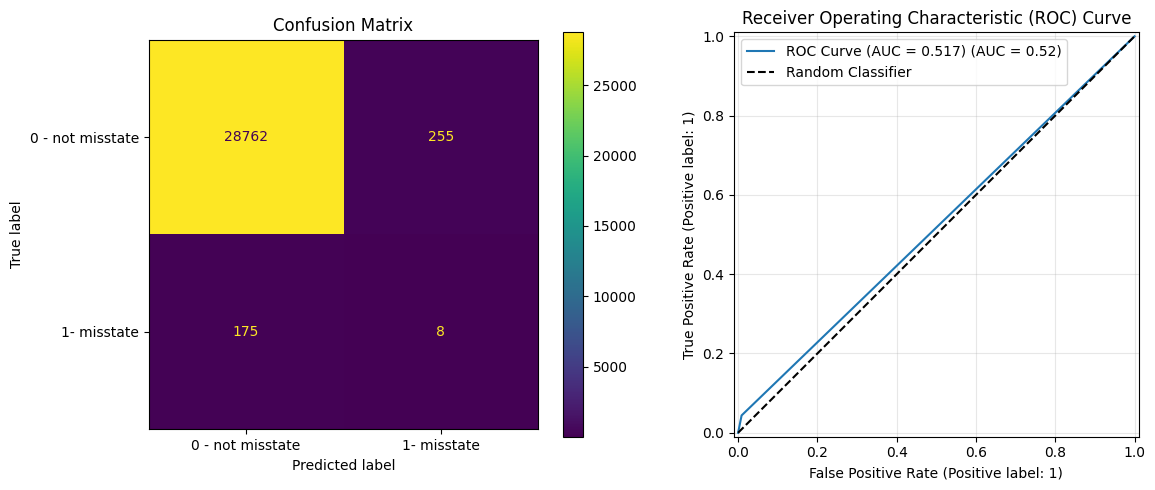

,Metric,Value
0,Specificity,0.9912
1,Recall/Sensitivity,0.0437
2,Precision,0.0304
3,F1-Score,0.0359
4,ROC AUC,0.5175


In [28]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
pred_dtc = dtc.predict(X_test)
dec_values_dtc = dtc.predict_proba(X_test)[:, 1]
calculate_metrics(y_test, pred_dtc, dec_values_dtc)

Slightly better. At least some hits on target with 8 true positives, but with thw price of increased number of false positives (we can see it in ROC AUC decreasing). And now we can start noticing that maybe F1 score is a promicing metric for our task.

#### HistGradientBoostingClassifier

HistGradientBoosting is a SOTA ensemble method based on Gradient Boosted Decision Trees (GBDT). It is specifically designed for large-scale datasets (over 10,000 samples) by binning continuous input variables into integer-coded buckets. Financial data is frequently characterized by extreme outliers and missing values. HGBC is robust to these issues because it can naturally handle NaN values (but this is not a primary goal in our case, since we've dealed with that problem already) and is invariant to the scale of the features (we partialy solved and that problem, normalizing the accounting items). By iteratively correcting the errors of previous trees, it is capable of modeling the subtle, high-dimensional patterns that distinguish fraudulent reports from legitimate financial volatility.

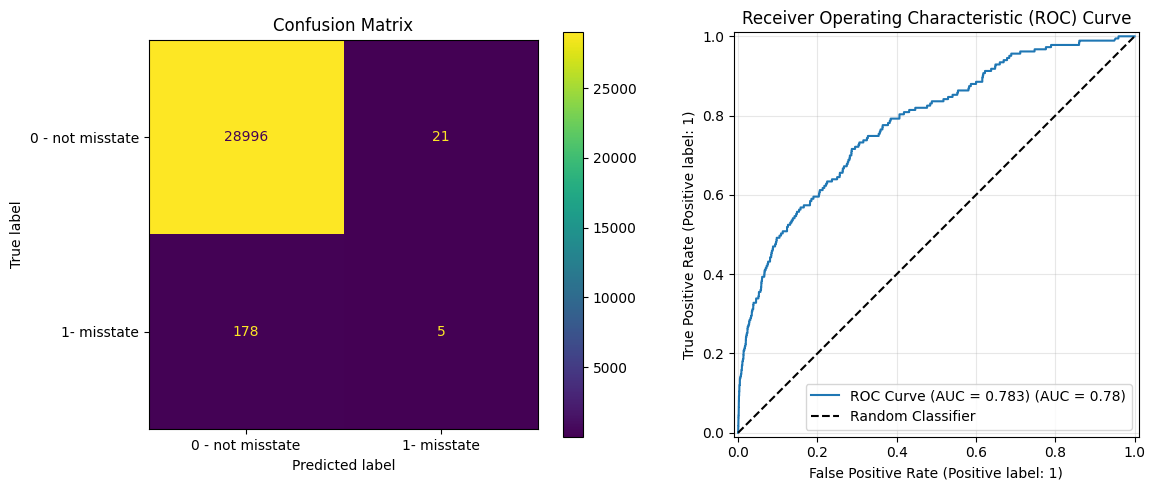

,Metric,Value
0,Specificity,0.9993
1,Recall/Sensitivity,0.0273
2,Precision,0.1923
3,F1-Score,0.0478
4,ROC AUC,0.7832


In [29]:
hgb = HistGradientBoostingClassifier(max_iter=200, random_state=42)
hgb.fit(X_train, y_train)
pred_hgb = hgb.predict(X_test)
dec_values_hgb = hgb.predict_proba(X_test)[:, 1]
calculate_metrics(y_test, pred_hgb, dec_values_hgb)

Here we again have not so many true positives, but we gain them with much less mistakes (false positives). The result is 'cleaner' and we can see that F1 scores reacts to that increasing.

#### Support Vector Classifier

While the Support Vector Classifier (SVC) is a powerful tool for high-dimensional data, it was excluded from further experimentation due to computational intractability.

It took ~1 hour to run the experiment with default parameters.

The training complexity of SVC typically scales between $O(n^2 \cdot m)$ and $O(n^3 \cdot m)$, where $n$ is the number of observations and $m$ is the number of features. Given our dataset size of over 146,000 observations, the quadratic scaling of the SVC made even baseline experiments with default parameters prohibitively time-consuming.

Furthermore, the baseline results yielded a Recall of 0.00, indicating that without extensive hyperparameter tuning and specialized kernels—which would require even greater computational resources—the model fails to identify the minority fraud class in a reasonable timeframe.

Consequently, we focus our efforts on more scalable algorithms, which are better suited for large-scale financial auditing tasks.

#### Some conclusions

1. Logistic Regression model achieved a Recall of 0.0000 and a Specificity of 1.0000, with 0 true positives. This model optimizes the loss function by simply predicting the majority class (Non-Fraud) for every single instance. While this results in high accuracy, the model is functionally useless for fraud detection as it identifies zero misstatements. The ROC AUC (0.72) suggests that while the default threshold (0.5) is failing, the model is successfully ranking fraud cases higher than non-fraud cases.

2. The DecisionTreeClassifier achieved a better result with 8 true positives, Recall at 0.0437 and low Precision (0.0304). The tree structure attempted to isolate fraud cases, but likely captured noise rather than signal. In a real-world scenario, this model would generate a massive number of false alarms (False Positives) for every actual fraud detected.

3. The HistGradientBoostingClassifier performed with 5 true positives, a Recall of 0.0273 and a ROC AUC (0.7832). The model provided only 5 true positive test answers, but without huge amount of false positives

The baseline results confirm that default classification thresholds are insufficient for fraud detection. The models are biased toward the majority class to minimize global error.

#### What can we do next?

- Implement cost-sensitive learning by assigning a higher penalty to misclassifying the minority class (Fraud) within the model parameters (e.g., class_weight='balanced').
- Experiment with resampling techniques: SMOTE, TomekLinks, SMOTETomek
- Model's parameters tuning with cross-validation
- Rather than using the default 0.5 probability threshold, we can utilize the "best threshold" to maximize the F1-Score

## Experiments with `class_weight` parameter implementation <a name="class_weight"></a>

#### Experimental setup

In this phase of the experiments, we shift from a naive baseline to a cost-sensitive learning approach. By implementing the `class_weight='balanced'` parameter, we explicitly instruct the models to place higher importance on the minority class (fraud), addressing the massive imbalance in our dataset (it basically means replicating the smaller class until you have as many samples as in the larger one, but in an implicit way).

The primary goal is to determine if adjusting the model's sensitivity to the minority class can overcome the difficulties observed in the baseline. Our main goal are:
- In fraud detection, the cost of a "False Negative" (missing a fraud) is significantly higher than a "False Positive" (extra auditing work). We prioritize catching more fraud cases.
- We compare performance across All Features, Accounting Items (Raw), and Financial Ratios to see if specific data types provide cleaner signals for the models.
- While we expect Precision to be low due to the 0.6% base rate, we seek a model that offers a meaningful trade-off for practical auditing.

So our ultimate goal is a maximum and balanced Precision/Recall

In [30]:
features = {'All features': FEATURE_COLS, 'Accounting items': RAW_COLS, 'Financial ratios': RATIO_COLS}
def run_cost_sensitive(model):
  y = data_norm[LABEL_COL]
  overall_results = pd.DataFrame()
  for k,v in features.items():
    X = data_norm[v]
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,shuffle=True)
    clf = model.fit(X_train, y_train)
    pred = clf.predict(X_test)
    dec_values = clf.predict_proba(X_test)[:, 1]
    print(f'Results for {k} features')
    results = calculate_metrics(y_test, pred, dec_values)
    results.loc[len(results)] = ["Features mode", k]
    overall_results = pd.concat([overall_results, results], axis=1)
    print('----------------------')
  return overall_results

#### Logistic Regression

Results for All features features


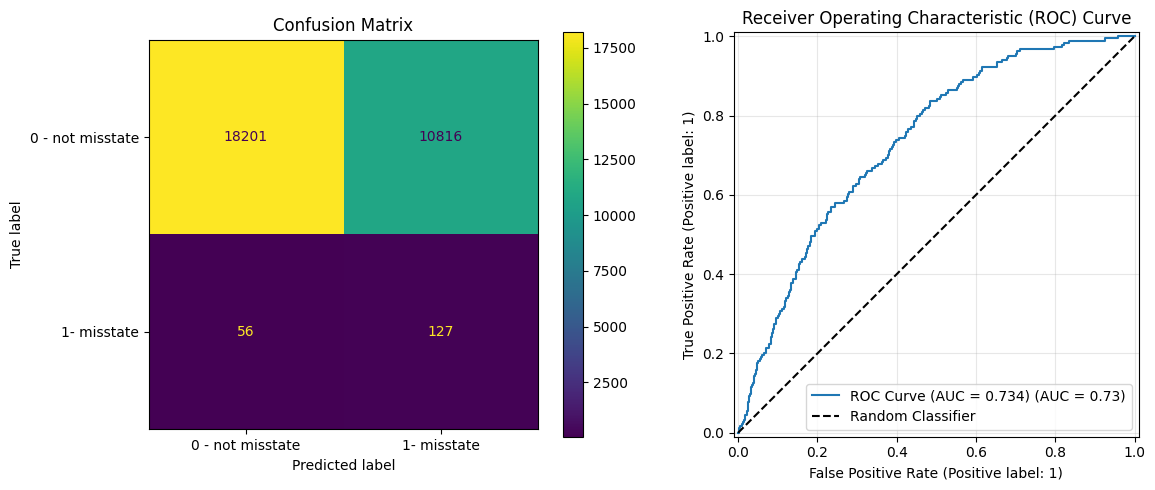

----------------------
Results for Accounting items features


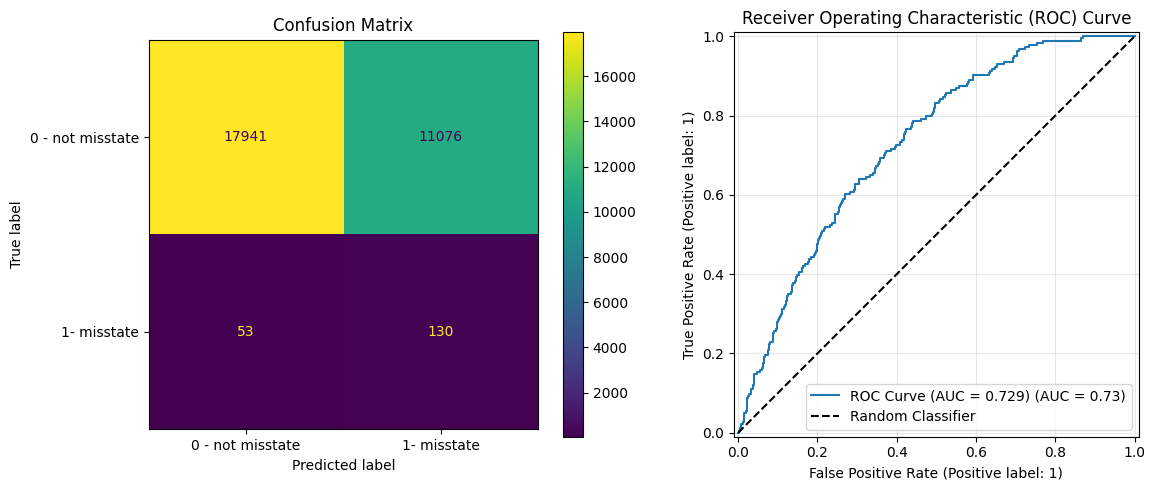

----------------------
Results for Financial ratios features


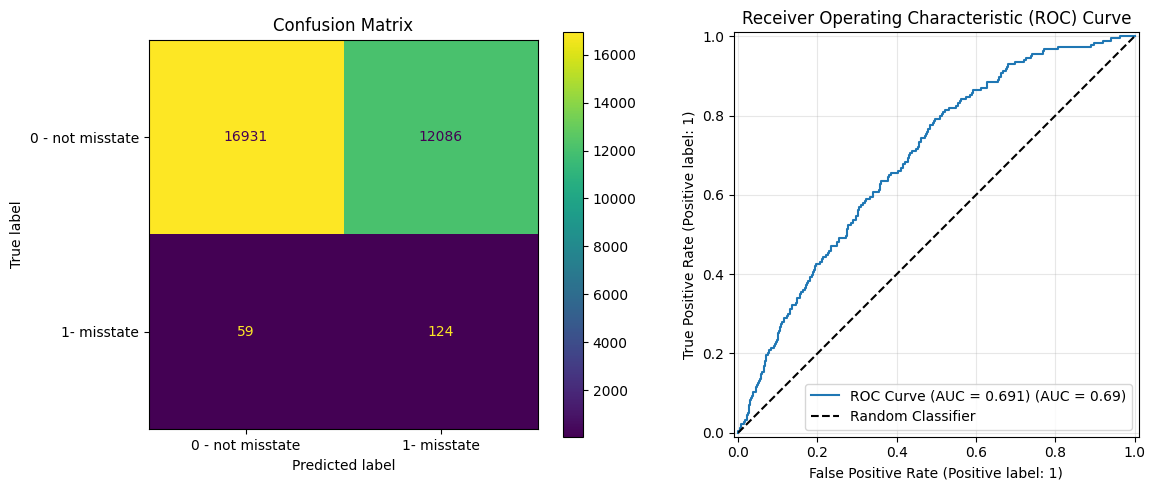

----------------------


,Metric,Value,Metric,Value,Metric,Value
0,Specificity,0.6273,Specificity,0.6183,Specificity,0.5835
1,Recall/Sensitivity,0.6940,Recall/Sensitivity,0.7104,Recall/Sensitivity,0.6776
2,Precision,0.0116,Precision,0.0116,Precision,0.0102
3,F1-Score,0.0228,F1-Score,0.0228,F1-Score,0.0200
4,ROC AUC,0.7339,ROC AUC,0.7292,ROC AUC,0.6913
5,Features mode,All features,Features mode,Accounting items,Features mode,Financial ratios


In [31]:
clf = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
run_cost_sensitive(clf)

#### Decision Tree

Results for All features features


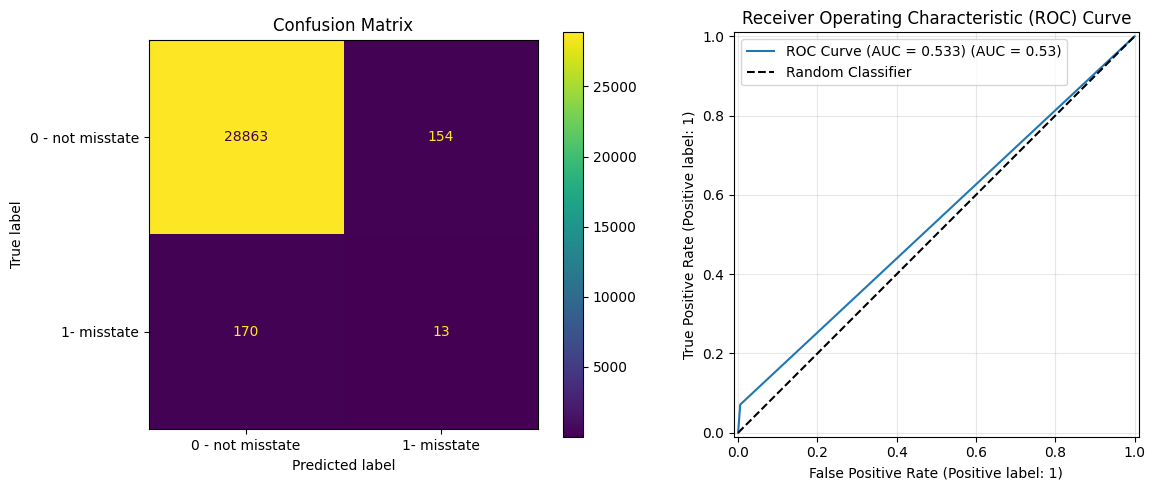

----------------------
Results for Accounting items features


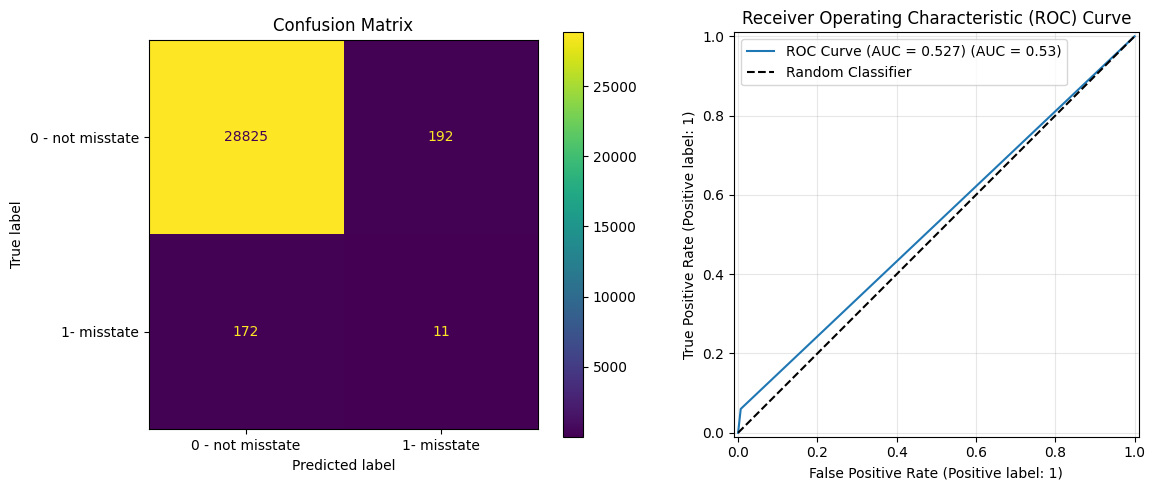

----------------------
Results for Financial ratios features


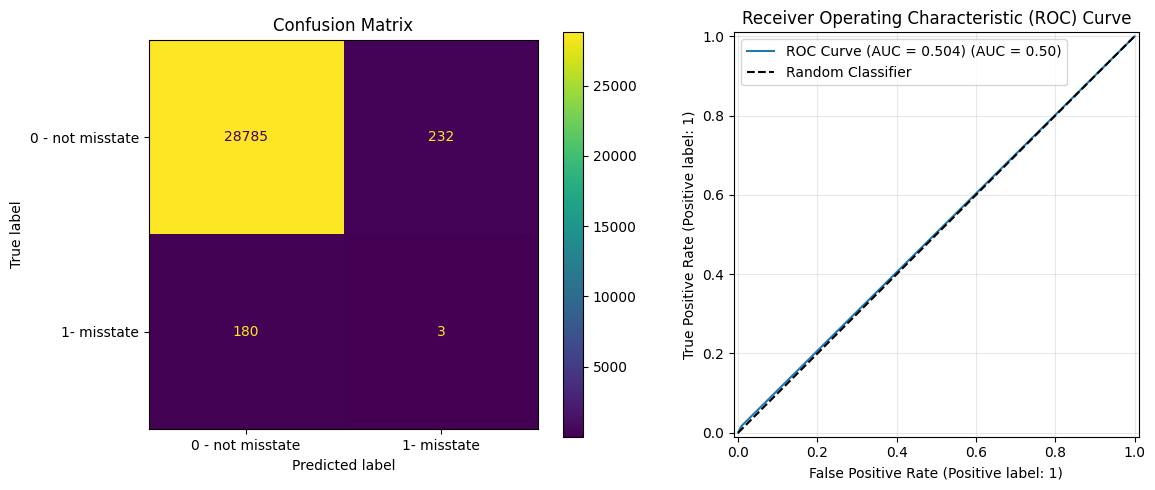

----------------------


,Metric,Value,Metric,Value,Metric,Value
0,Specificity,0.9947,Specificity,0.9934,Specificity,0.9920
1,Recall/Sensitivity,0.0710,Recall/Sensitivity,0.0601,Recall/Sensitivity,0.0164
2,Precision,0.0778,Precision,0.0542,Precision,0.0128
3,F1-Score,0.0743,F1-Score,0.0570,F1-Score,0.0144
4,ROC AUC,0.5329,ROC AUC,0.5267,ROC AUC,0.5042
5,Features mode,All features,Features mode,Accounting items,Features mode,Financial ratios


In [32]:
dtc = DecisionTreeClassifier(random_state=42, class_weight='balanced')
run_cost_sensitive(dtc)

#### HistGradientBoostingClassifier

Results for All features features


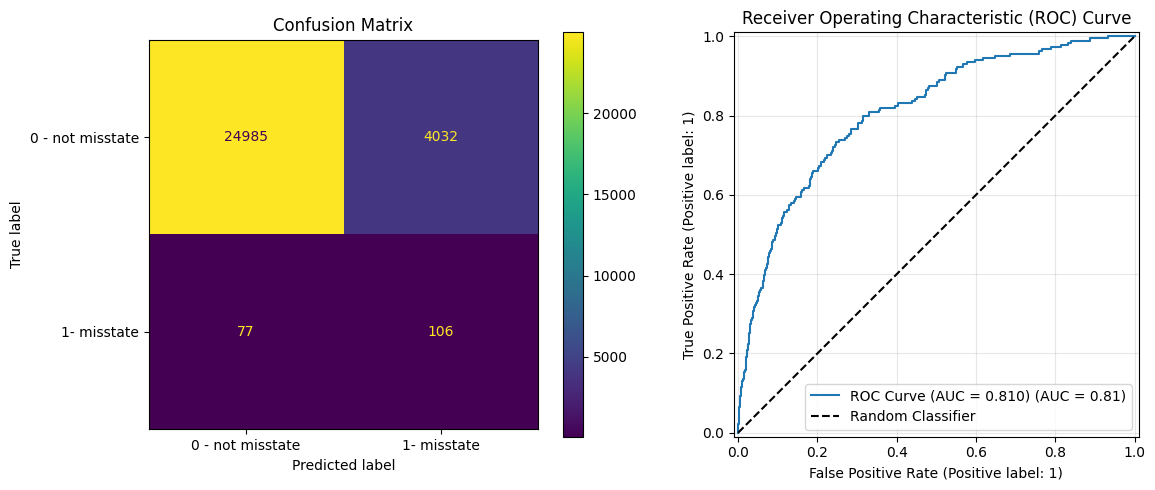

----------------------
Results for Accounting items features


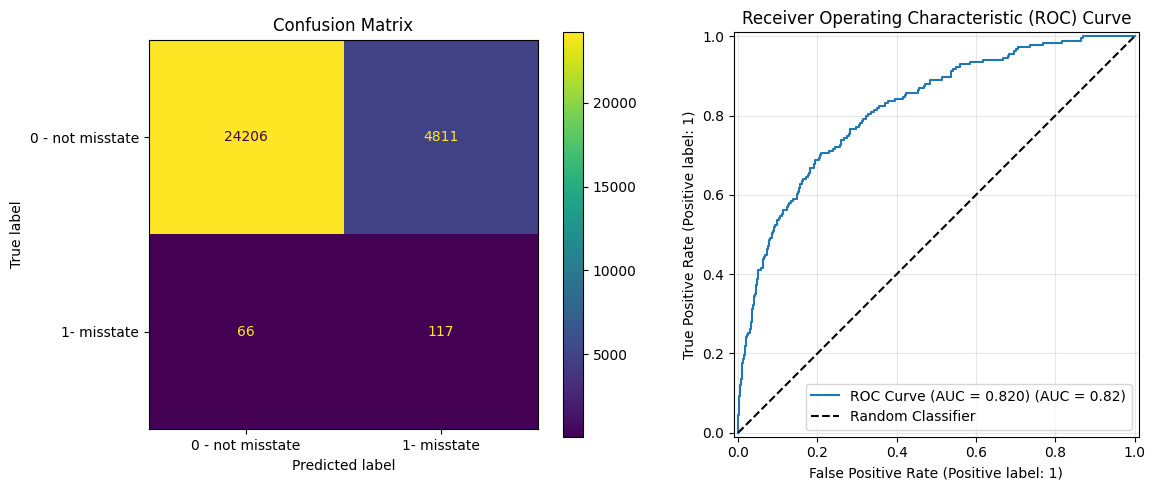

----------------------
Results for Financial ratios features


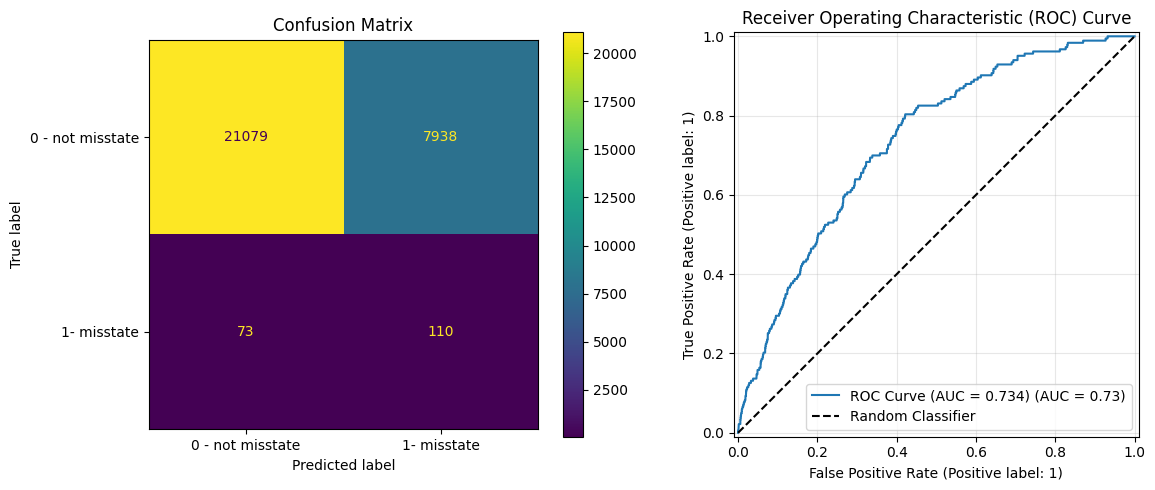

----------------------


,Metric,Value,Metric,Value,Metric,Value
0,Specificity,0.8610,Specificity,0.8342,Specificity,0.7264
1,Recall/Sensitivity,0.5792,Recall/Sensitivity,0.6393,Recall/Sensitivity,0.6011
2,Precision,0.0256,Precision,0.0237,Precision,0.0137
3,F1-Score,0.0491,F1-Score,0.0458,F1-Score,0.0267
4,ROC AUC,0.8096,ROC AUC,0.8195,ROC AUC,0.7337
5,Features mode,All features,Features mode,Accounting items,Features mode,Financial ratios


In [33]:
hgb = HistGradientBoostingClassifier(max_iter=500, random_state=42, class_weight='balanced')
run_cost_sensitive(hgb)

#### Conclusions

* Logistic Regression responded most significantly to cost-weighting. Recall jumped from 0.00 (baseline) to approximately 0.67–0.71. This came at the cost of Specificity, which dropped to ~0.60. The model is now acting as an aggressive filter. It identifies roughly 70% of all fraud cases, but it flags 40% of legitimate companies as "suspicious." For a regulatory body like the SEC, this might result in too many "False Alarms" (Precision is only ~1%).

* Despite the balanced weights, the Decision Tree remains largely ineffective. ROC AUC remains near 0.50-0.53, which is effectively random guessing. Decision trees are prone to overfitting the noise in imbalanced datasets. Even with class weighting, the tree splits on idiosyncratic features of the training data rather than generalizable fraud patterns.

* The HistGradientBoosting model provides the most sophisticated results of this experiment. It achieves a ROC AUC of 0.81-0.82 and a Recall of 0.58-0.64. Unlike Logistic Regression, HGB maintains a much higher Specificity (~0.83-0.86). HGB is the most efficient (among three models) at "ranking" fraud. It catches a majority of fraud cases while only flagging ~15% of non-fraudulent firms. This is visible in the higher F1-score and ROC AUC compared to the other models.

* A significant finding from your results is the performance of "Accounting Items" and "Financial Ratios." For the HGB model, using Raw Accounting Items actually yielded the highest ROC AUC (0.8195) and the highest Recall (0.6393). This suggests that the Gradient Boosting model is capable of internally "learning" the necessary ratios and size-adjustments from raw data, sometimes more effectively than using pre-calculated ratios that may lose specific information.

Cost-sensitive learning has moved our models away (not too far though) from the "predict everything as 0" trap. We now have models that can identify some portion of fraud.

To further refine these results and try to improve Precision, we can fine-tune our models with cross-validation and then move beyond simple weighting and implement Resampling Techniques (SMOTE/Tomek/SMOTETomek) combined with the best model (after cross-validation).

## Experiments with cross-validation <a name="accounting_features"></a>

To compare our three candidate architectures, we implement a nested cross-validation procedure with 5 outer trials and 2-fold stratified splits.

This approach provides an unbiased estimate of generalization performance by separating the hyperparameter optimization (inner loop) from the model evaluation (outer loop).

We prioritize the F1-Score as our primary optimization metric in the inner loop to mitigate the extreme class imbalance. The resulting performance metrics, averaged across all 10 outer folds (5 trials x 2 splits), provide the statistical basis for selecting our champion model for future experimentation.

The problem with using such a setup is it's time complexity. The slow performance is due to the combinatorial explosion of cross-validation folds.

Model fits = Trials x Outer folds x Inner repeats x Inner folds x Grid combinations = (40 x Grid combinations) model fits per algorithm.

* Logistic Regression: 40 x (3 x 2 x 1 x 1) = 240
* Decision Tree: 40 x (2 x 3 x 4 x 1) = 960
* HistGradientBoosting Classifier: 40 x (3 x 3 x 3 x 3 x 1)  = 1080


In [34]:
y = data_norm[LABEL_COL]
X = data_norm[FEATURE_COLS]

NUM_TRIALS = 5 #outer repetitions
NUM_INNER_REPEATS = 2 #outer folds
NUM_INNER_SPLITS = 2 #inner repeats
NUM_OUTER_SPLITS = 2 #inner folds

log_reg_grid = {'model__C': [0.01, 0.1, 1, 10],           # Controls the inverse of regularization strength; smaller values prevent the model from overfitting
                'model__penalty': ['l1', 'l2'],           # l1 (Lasso) acts as a feature selector; l2 (Ridge) helps handle multicollinearity between accounting items.
                'model__solver': ['liblinear'],           # for l1 support and efficient for datasets with $N > 100,000$.
                'model__class_weight': ['balanced']}

tree_grid = {'model__criterion': ['gini', 'entropy'],     # different measures of impurity to see which better isolates the rare fraud class.
             'model__min_samples_split' : [10, 20, 50],   # a number of samples to split a node; ensuring that the "fraud" rules captured are statistically significant.
             'model__max_depth': [3, 5, 7, 10],           # prevents the tree from growing deep enough to memorize unique noise in specific year-company instances.
             'model__class_weight': ['balanced']}

hgbc_grid = {'model__learning_rate': [0.01, 0.05, 0.1],   # smaller rates - better generalization, but more iterations; essential for capturing subtle fraud patterns.
             'model__max_iter': [100, 300, 500],          # the number of boosting rounds; given the size of the data, more iterations allow for deeper refinement.
             'model__max_depth': [3, 5, None],            # limits the complexity of each individual tree; shallow trees (stumps) are often more robust to extreme outliers.
             'model__l2_regularization': [0.0, 0.1, 1.0], # adds a penalty to the loss function (for stabilizing the model against the high kurtosis)
             'model__class_weight': ['balanced']}

# Specificity is just Recall of the negative class
def specificity_score(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=0)

scoring = {'f1': 'f1', 'precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc', 'specificity': make_scorer(specificity_score)}

def nested_cv(estimator, grid, features, targets):
    start = time.time()
    f1 = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    spec = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    prec = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    recall = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    roc_auc = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    fit_times = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    test_times = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))

    for i in range(NUM_TRIALS):
        print("Running Outer CV in iteration: ", i, " at ", time.time()-start)

        pipe = Pipeline([('model', estimator)])

        inner_cv = RepeatedStratifiedKFold(n_splits=NUM_INNER_SPLITS, n_repeats=NUM_INNER_REPEATS, random_state=i)
        outer_cv = StratifiedKFold(n_splits=NUM_OUTER_SPLITS, shuffle=True, random_state=i)

        clf = GridSearchCV(estimator=pipe, param_grid=grid, cv=inner_cv, scoring='f1', n_jobs=-1)
        cv_result = cross_validate(clf, X=X, y=y, cv=outer_cv, scoring=scoring, n_jobs=-1)

        f1[i] = cv_result['test_f1']
        spec[i] = cv_result['test_specificity']
        prec[i] = cv_result['test_precision']
        recall[i] = cv_result['test_recall']
        roc_auc[i] = cv_result['test_roc_auc']
        fit_times[i] = cv_result['fit_time']
        test_times[i] = cv_result['score_time']

    print('Total time: ', (time.time()-start), 'sec.')
    return f1, spec, prec, recall, roc_auc, fit_times, test_times


def add_result(results, name, f1, spec, prec, recall, roc_auc, fit_times, test_times):
    row = {'name': name, 'f1_mean': f1.mean(), 'f1_std': f1.std(),
                         'spec_mean': spec.mean(), 'spec_std': spec.std(),
                         'prec_mean': prec.mean(), 'prec_std': prec.std(),
                         'recall_mean': recall.mean(), 'recall_std': recall.std(),
                         'roc_auc_mean': roc_auc.mean(), 'roc_auc_std': roc_auc.std(),
                         'fit_time': fit_times.mean(), 'test_time': test_times.mean()
          }
    return pd.concat([results, pd.DataFrame([row])], ignore_index=True)

The metrics are calculated from the best models found during the inner loops, but evaluated on the unseen outer folds. This is the core strength of Nested Cross-Validation. It doesn't just tell us how well a specific set of parameters works; it tells how well the model-selection process generalizes to new data.

How the metrics are calculated? Outer loop splits data into a "Training + Validation" set and a "Test" set. Inner loop (GridSearchCV) takes that "Training + Validation" set, tries every combination in the grid, and uses internal cross-validation to pick the best parameters. The cross_validate function then takes that "best" model and tests it on the "Test" set from the Outer loop (evaluation). Final metrics are the average results of those "best" models.

After we see that a model performs best across all folds, we will then run a single GridSearchCV on the entire dataset to get the final parameters to use in following experiments

F1-score was chosen as the strategy to evaluate the performance of the cross-validated model on the test set. F1 calculates the harmonic mean of precision and recall, it provides a balanced performance view, making it appropriate for imbalanced datasets where the minority class is important (advocated by Andrews Ng).

In [35]:
results = pd.DataFrame()

In [36]:
logistic_regression = LogisticRegression(max_iter=500, random_state=42)
f1, spec, prec, recall, roc_auc, fit_times, test_times = nested_cv(logistic_regression, log_reg_grid, X, y)
results = add_result(results, 'logistic_regression', f1, spec, prec, recall, roc_auc, fit_times, test_times)

Running Outer CV in iteration:  0  at  1.7881393432617188e-05
Running Outer CV in iteration:  1  at  576.7765953540802
Running Outer CV in iteration:  2  at  1112.2751059532166
Running Outer CV in iteration:  3  at  1724.2892580032349
Running Outer CV in iteration:  4  at  2152.1324379444122
Total time:  2693.2601573467255 sec.


In [37]:
decision_tree = DecisionTreeClassifier(random_state=42)
f1, spec, prec, recall, roc_auc, fit_times, test_times = nested_cv(decision_tree, tree_grid, X, y)
results = add_result(results, 'decision_tree', f1, spec, prec, recall, roc_auc, fit_times, test_times)

Running Outer CV in iteration:  0  at  2.4080276489257812e-05
Running Outer CV in iteration:  1  at  291.15922260284424
Running Outer CV in iteration:  2  at  584.8511521816254
Running Outer CV in iteration:  3  at  872.9685668945312
Running Outer CV in iteration:  4  at  1165.2441368103027
Total time:  1459.2376675605774 sec.


In [38]:
hgb = HistGradientBoostingClassifier(max_iter=500, random_state=42)
f1, spec, prec, recall, roc_auc, fit_times, test_times = nested_cv(hgb, hgbc_grid, X, y)
results = add_result(results, 'hist_gradient_boosting', f1, spec, prec, recall, roc_auc, fit_times, test_times)

Running Outer CV in iteration:  0  at  1.9311904907226562e-05
Running Outer CV in iteration:  1  at  826.0579679012299
Running Outer CV in iteration:  2  at  1580.1992962360382
Running Outer CV in iteration:  3  at  2335.0697503089905
Running Outer CV in iteration:  4  at  3190.6372878551483
Total time:  3984.1364753246307 sec.


In [39]:
results

,name,f1_mean,f1_std,spec_mean,spec_std,prec_mean,prec_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std,fit_time,test_time
0,logistic_regression,0.024720,0.000637,0.640520,0.008869,0.012586,0.000326,0.689212,0.020281,0.732199,0.008551,521.822942,0.117858
1,decision_tree,0.029183,0.001929,0.788677,0.024481,0.015051,0.001017,0.483817,0.045783,0.646530,0.017756,290.386231,0.124153
2,hist_gradient_boosting,0.046943,0.001964,0.866056,0.010013,0.024617,0.001105,0.507054,0.019643,0.794802,0.007948,768.414663,1.146113


#### Find the best parameters

Select the best model based on mean outer F1

In [40]:
best_model_name = results.loc[results['f1_mean'].idxmax(), 'name']
print("Best model based on outer CV F1:", best_model_name)

Best model based on outer CV F1: hist_gradient_boosting


Refit the best model on full data and print the best parameters

In [41]:
if best_model_name == 'logistic_regression':
    best_estimator = LogisticRegression(max_iter=500)
    best_grid = log_reg_grid
elif best_model_name == 'decision_tree':
    best_estimator = DecisionTreeClassifier()
    best_grid = tree_grid
else:
    best_estimator = HistGradientBoostingClassifier(max_iter=500)
    best_grid = hgbc_grid

pipe = Pipeline([('model', best_estimator)])
param_grid = {key: value for key, value in best_grid.items()}

inner_cv = RepeatedStratifiedKFold(n_splits=NUM_INNER_SPLITS, n_repeats=NUM_INNER_REPEATS, random_state=42)
final_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=inner_cv, scoring='f1', n_jobs=-1)
final_search.fit(X, y)

print("\nFinal best parameters:")
print(final_search.best_params_)
print("Final best inner CV F1:", final_search.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Final best parameters:
{'model__class_weight': 'balanced', 'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_iter': 100}
Final best inner CV F1: 0.04694993755601017


## Experiments with resampling implementation <a name="resampling"></a>


The extreme class imbalance observed in our dataset, where fraud cases represent only 0.66% of total observations (a 150:1 ratio), complecates supervised learning. When faced with such "skewed" data, standard objective functions like Binary Cross-Entropy often converge on a trivial solution, achieving 99.34% accuracy, by simply predicting the majority class for every instance, resulting in a zero Recall.

In this section, we transition from model-based interventions (such as `class_weight` adjustments) to data-level interventions. This approach is rooted in the "model-centric" school of thought, which argues that the minority signal is often subsumed by statistical noise in its original distribution. To force the learner to establish more robust decision boundaries, we will evaluate three primary resampling strategies:

* SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic examples to densify the minority feature space rather than mere replication.
* Tomek Links, an undersampling method that identifies and removes "ambiguous" majority class examples located near the decision boundary to clean the class overlap.
* SMOTETomek, a hybrid approach that combines synthetic over-sampling with boundary cleaning to provide a more distinct signal for the classifier.

A critical constraint in these experiments is the prevention of data leakage. We have to split the data into training and test sets before applying any resampling. Resampling the entire dataset prior to splitting would allow identical or near-identical synthetic observations to exist in both sets, leading to "overly optimistic" and invalid performance metrics.

While these techniques are designed to improve Recall, we must remain critical of their impact on model calibration. Academic literature warns that "messing with the data" through resampling can irrevocably distort the model's ability to produce real-world, calibrated probabilities. By artificially balancing the classes, we may improve the F1-score at the cost of rendering the `predict_proba` outputs meaningless for actual risk assessment.

In [42]:
def print_size(X_resampled, y_resampled, X_test, y_test):
    print(f'Size of training set: {X_resampled.shape[0], y_resampled.shape[0]}\n')
    print(f'Size of test set: {X_test.shape[0], y_test.shape[0]}\n')
    print(f'Train set structure: 0 - no misstate, 1- misstate:\n {y_resampled.value_counts()}\n')
    print(f'Test set structure: 0 - no misstate, 1- misstate:\n {y_test.value_counts()}')

def resampling_experiments(strategy=None):
  y = data_norm[LABEL_COL]
  X = data_norm[FEATURE_COLS]

  X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=42,
                                                      shuffle=True)

  if strategy=='SMOTE':
    sm = SMOTE(random_state=42, sampling_strategy='minority')
    X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
    print_size(X_resampled, y_resampled, X_test, y_test)

    pipe = Pipeline([
    ('sampling', SMOTE(random_state=42)),
    ('model', HistGradientBoostingClassifier(max_iter=500, random_state=42))])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    dec_values = pipe.predict_proba(X_test)[:, 1]

    return calculate_metrics(y_test, pred, dec_values)


  elif strategy=='Tomek':
    tl = TomekLinks(sampling_strategy='majority')
    X_resampled, y_resampled = tl.fit_resample(X_train, y_train)
    print_size(X_resampled, y_resampled, X_test, y_test)

    pipe = Pipeline([
        ('sampling', TomekLinks()),
        ('model', HistGradientBoostingClassifier(max_iter=500, random_state=42))])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    dec_values = pipe.predict_proba(X_test)[:, 1]

    return calculate_metrics(y_test, pred, dec_values)

  elif strategy=='SMOTETomek':
    smt = SMOTETomek(random_state=42)
    X_resampled, y_resampled = smt.fit_resample(X_train, y_train)
    print_size(X_resampled, y_resampled, X_test, y_test)

    pipe = Pipeline([
        ('sampling', SMOTETomek(random_state=42)),
        ('model', HistGradientBoostingClassifier(max_iter=500, random_state=42))])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    dec_values = pipe.predict_proba(X_test)[:, 1]

    return calculate_metrics(y_test, pred, dec_values)

#### SMOTE implementation

Size of training set: (232036, 232036)

Size of test set: (29200, 29200)

Train set structure: 0 - no misstate, 1- misstate:
 misstate
0    116018
1    116018
Name: count, dtype: int64

Test set structure: 0 - no misstate, 1- misstate:
 misstate
0    29017
1      183
Name: count, dtype: int64


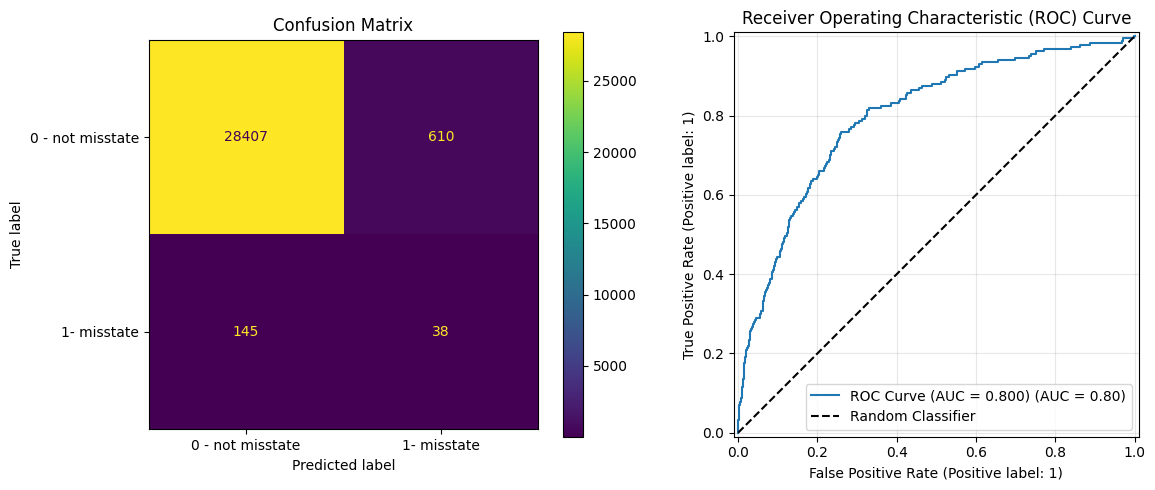

,Metric,Value
0,Specificity,0.9790
1,Recall/Sensitivity,0.2077
2,Precision,0.0586
3,F1-Score,0.0915
4,ROC AUC,0.7997


In [43]:
resampling_experiments(strategy='SMOTE')

#### Tomek implementation <a name="Tomek"></a>

"Tomek Links" is a fairly expensive algorithm since it has to compute pairwise distances between all examples.

Size of training set: (116532, 116532)

Size of test set: (29200, 29200)

Train set structure: 0 - no misstate, 1- misstate:
 misstate
0    115751
1       781
Name: count, dtype: int64

Test set structure: 0 - no misstate, 1- misstate:
 misstate
0    29017
1      183
Name: count, dtype: int64


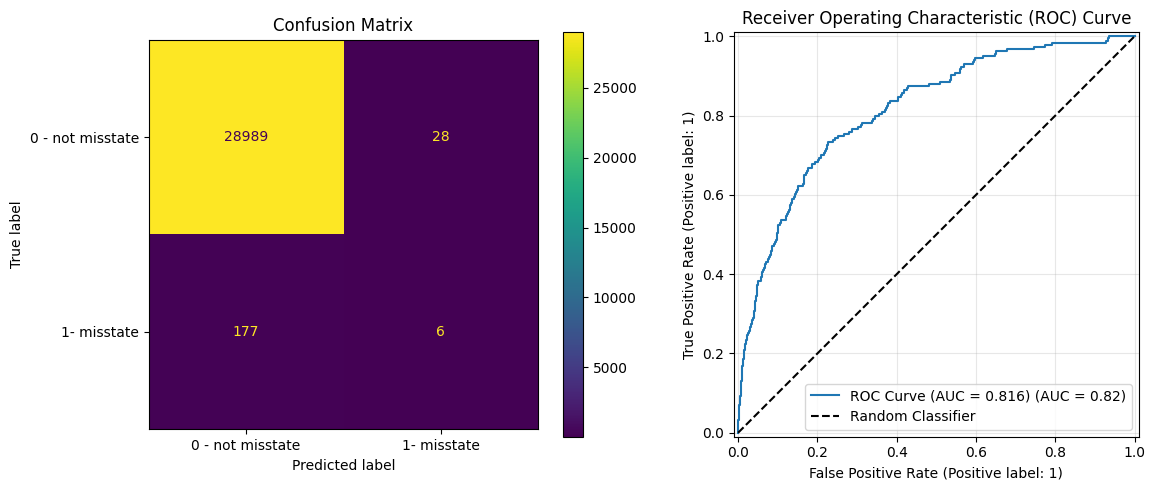

,Metric,Value
0,Specificity,0.9990
1,Recall/Sensitivity,0.0328
2,Precision,0.1765
3,F1-Score,0.0553
4,ROC AUC,0.8160


In [44]:
resampling_experiments(strategy='Tomek')

#### SMOTETomek implementation <a name="smote-tomek"></a>

Over-sampling using SMOTE and cleaning using Tomek links.

Combine over- and under-sampling using SMOTE and Tomek links.

Size of training set: (232018, 232018)

Size of test set: (29200, 29200)

Train set structure: 0 - no misstate, 1- misstate:
 misstate
0    116009
1    116009
Name: count, dtype: int64

Test set structure: 0 - no misstate, 1- misstate:
 misstate
0    29017
1      183
Name: count, dtype: int64


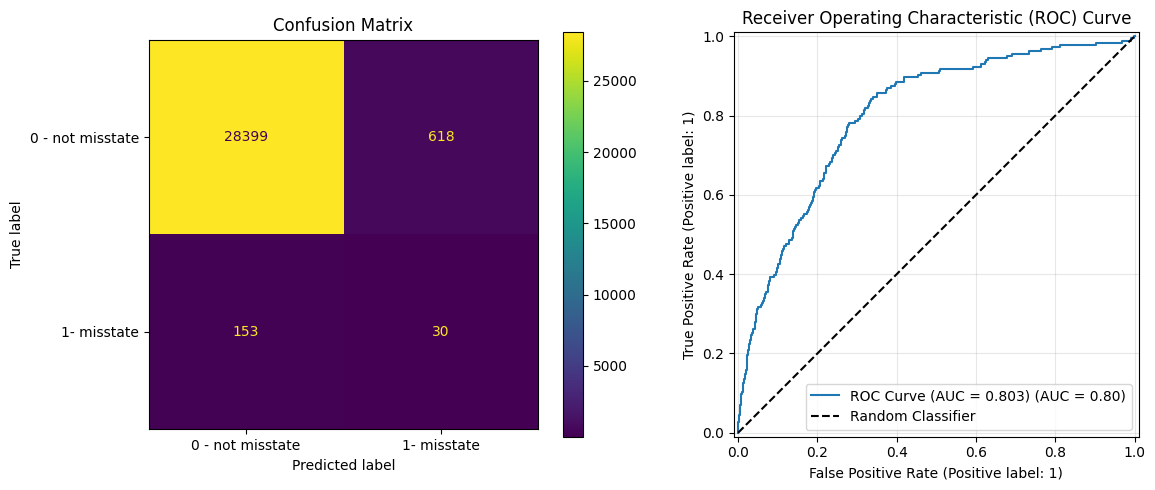

,Metric,Value
0,Specificity,0.9787
1,Recall/Sensitivity,0.1639
2,Precision,0.0463
3,F1-Score,0.0722
4,ROC AUC,0.8034


In [45]:
resampling_experiments(strategy='SMOTETomek')

* SMOTE creates synthetic samples of the minority class. It blew up the training set from ~116k rows to ~232K rows by creating copies/variations of the 781 minority samples. It forced the dataset to be perfectly balanced (116,018 vs. 116,018).
* Tomek Links is an under-sampling cleaning technique. It removes samples from the majority class that are very close to the minority class (the "Tomek Links") to clean the decision boundary. It reduced your training set slightly from ~117k to ~116K. It did not balance the classes. It left the imbalance almost exactly as it was (115,751 vs. 781).
* Which is better? It depends on the business goal. If the goal is to catch as many misstatements as possible (even if you have to manually check some false alarms): SMOTE is better (20% recall vs 3% recall). The F1-Score is higher, and the ROC AUC is comparable. If false alarms are extremely expensive (e.g., auditing a false positive costs $10K): The Tomek method (High Specificity/Precision) might be preferable, but a 3% recall rate is likely unacceptable for a fraud/misstatement detection task.

## Experiments with probability calibration curves <a name="calibration"></a>

Very insightful [video](https://www.youtube.com/watch?v=6YnhoCfArQo) from the EuroSciPy 2023 scikit-learn contributor (I may be wrong, but I think he emplemeted resampling techiques to the library).

The main idea is that there is no problem learning from the imbalance data and we do not need to use any resampling techniques (because no resampling tecnique will magically generate more information out of the few cases with the rare class). Resampling is used to alleviate the inflexibility of decision threshold (0.5 by default), but it renders the interpretation of the values returned by `model.predict_proba` meaningless and it breaks calibration. What can we do instead is to post-tune the estimator decision threshold with `TunedThresholdClassifier`.

For this experiment we need Expected Calibration Error (ECE), which measures how well a model's predicted probabilities match its actual accuracy.

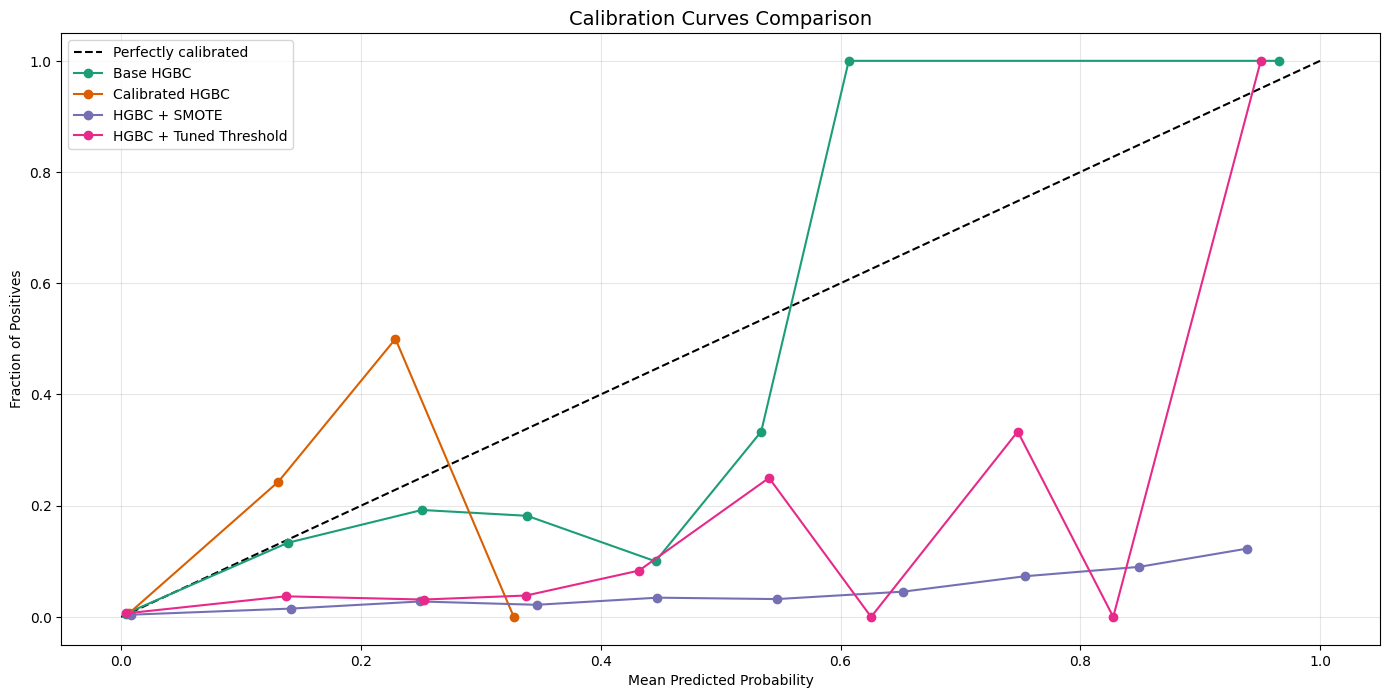

,Brier,ROC-AUC,PR-AUC,ECE,y_prob
Base HGBC,0.006408,0.820087,0.070766,0.002339,"[0.0010886907775673315, 0.0004714260819131028,..."
Calibrated HGBC,0.006378,0.825692,0.070905,0.00028,"[0.0033656315996968764, 0.0011897076901837352,..."
HGBC + SMOTE,0.019943,0.805905,0.041697,0.034315,"[0.0003234682054177983, 1.0390980175987086e-05..."
HGBC + Tuned Threshold,0.006845,0.809862,0.046258,0.003955,"[0.0013441085734680655, 0.0004717269511062219,..."


In [46]:
# Expected Calibration Error

def compute_ece(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bin_edges) - 1

    ece = 0
    for i in range(n_bins):
        mask = bin_ids == i
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            weight = np.sum(mask) / len(y_true)
            ece += weight * np.abs(acc - conf)
    return ece


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Define Models

base = HistGradientBoostingClassifier(l2_regularization= 0.1, learning_rate=0.1, max_depth=None, max_iter=500, random_state=42)
calibrated = CalibratedClassifierCV(base, method="sigmoid", cv=5)
smote_model = ImbPipeline([("smote", SMOTE(random_state=42)), ("model", HistGradientBoostingClassifier(max_iter=500, random_state=42))])
threshold_tuned = TunedThresholdClassifierCV(estimator=HistGradientBoostingClassifier(max_iter=500, random_state=42), scoring="balanced_accuracy", cv=5)
models = {"Base HGBC": base, "Calibrated HGBC": calibrated, "HGBC + SMOTE": smote_model, "HGBC + Tuned Threshold": threshold_tuned}

# Fit Models

for model in models.values():
    model.fit(X_train, y_train)

# Plot Calibration Comparison

def plot_calibration_comparison(models, X_test, y_test, n_bins=10):

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 3)

    ax_cal = fig.add_subplot(gs[0:2, :])
    ax_cal.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")

    colors = plt.cm.Dark2.colors
    metrics_summary = {}

    for i, (name, model) in enumerate(models.items()):
        y_prob = model.predict_proba(X_test)[:, 1]
        frac_pos, mean_pred = calibration_curve(y_test, y_prob,n_bins=n_bins,strategy="uniform")
        ax_cal.plot(mean_pred, frac_pos,marker="o",linewidth=1.5,label=name,color=colors[i % len(colors)])
        metrics_summary[name] = {"Brier": brier_score_loss(y_test, y_prob),"ROC-AUC": roc_auc_score(y_test, y_prob),
                                 "PR-AUC": average_precision_score(y_test, y_prob),"ECE": compute_ece(y_test, y_prob, n_bins=n_bins),"y_prob": y_prob}

    ax_cal.set_title("Calibration Curves Comparison", fontsize=14)
    ax_cal.set_xlabel("Mean Predicted Probability")
    ax_cal.set_ylabel("Fraction of Positives")
    ax_cal.legend()
    ax_cal.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    metrics_summary = pd.DataFrame(metrics_summary).T
    return metrics_summary


plot_calibration_comparison(models, X_test, y_test)

#### Conclusions

1. Base HGBC
* ROC-AUC = 0.82 → modest ranking ability
* PR-AUC = 0.0708 → modest but expected in rare-event setting
* ECE = 0.0023 → already very well calibrated
* Actually a strong baseline.


2. Calibrated HGBC
* ROC-AUC slightly improved
* PR-AUC slightly improved
* Brier slightly improved
* ECE dropped from 0.0023 → 0.00028
Calibration:
- Does NOT change ranking
- Improves probability accuracy
- Slightly improves proper scoring rules

3. HGBC + SMOTE
* ROC-AUC decreased - worse ranking
* PR-AUC decreased - worse minority detection
* Brier increased - worse calibration
* ECE increased - miscalibration
SMOTE clearly damaged ranking, calibration and probability meaning. SMOTE shifts class prior and distorts posterior probabilities. SMOTE curve sitting far from diagonal. Strong underconfidence at high probabilities

4. Tuned Threshold
Threshold tuning does not change probabilities.
* ECE still low
* Brier still low
* Calibration curve similar to base

What model is the best? Depends on goal:
- If you want calibrated probabilities -> Calibrated HGBC
- If you want best ranking -> Calibrated HGBC
- If you want recall optimization -> Tuned threshold


Optimal threshold found by CV: 0.010165

Base @ 0.5
Precision: 0.6
Recall   : 0.015544041450777202
F1-score : 0.030303030303030304

Base @ Optimized Threshold
Precision: 0.03886127428829643
Recall   : 0.44559585492227977
F1-score : 0.0714879467996675

SMOTE @ 0.5
Precision: 0.061191626409017714
Recall   : 0.19689119170984457
F1-score : 0.09336609336609336


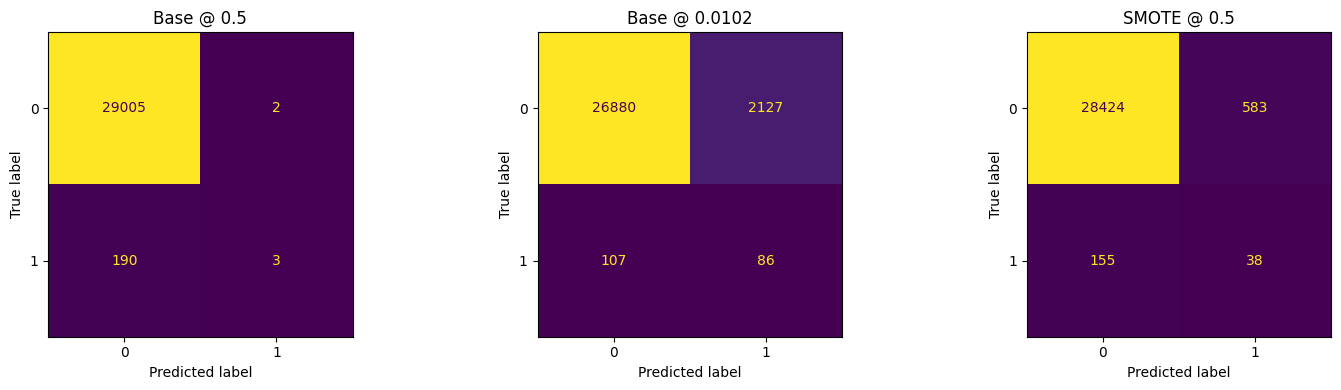

In [47]:
# probabilities from BASE model
base_probs = base.predict_proba(X_test)[:, 1]

# default threshold = 0.5
y_pred_default = (base_probs >= 0.5).astype(int)

# optimized threshold from tuned model
optimal_threshold = threshold_tuned.best_threshold_
print(f"\nOptimal threshold found by CV: {optimal_threshold:.6f}")

y_pred_optimized = (base_probs >= optimal_threshold).astype(int)

# SMOTE predictions (for comparison)
smote_probs = smote_model.predict_proba(X_test)[:, 1]
y_pred_smote = (smote_probs >= 0.5).astype(int)

# confusion matrices
cm_default = confusion_matrix(y_test, y_pred_default)
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
cm_smote = confusion_matrix(y_test, y_pred_smote)

def print_metrics(name, y_true, y_pred):
    print(f"\n{name}")
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))

print_metrics("Base @ 0.5", y_test, y_pred_default)
print_metrics("Base @ Optimized Threshold", y_test, y_pred_optimized)
print_metrics("SMOTE @ 0.5", y_test, y_pred_smote)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay(cm_default).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Base @ 0.5")
ConfusionMatrixDisplay(cm_optimized).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Base @ {optimal_threshold:.4f}")
ConfusionMatrixDisplay(cm_smote).plot(ax=axes[2], colorbar=False)
axes[2].set_title("SMOTE @ 0.5")
plt.tight_layout()
plt.show()

`Optimal threshold found by CV: 0.010165` is extremely small, and expected:
*The true positive rate is very low.
* The optimal decision boundary for PR-AUC/F1 is nowhere near 0.5.
* Using 0.5 in rare-event classification is statistically unjustified.



1. Base Model @ 0.5 : when it predicts positive, it's usually correct, but it almost never predicts positive. So, nearly all positives are missed, it's extremely conservative.
2. Base @ 0.0102 (optimized) : now the model detect ~45% of positives, we accept more false positives. The model had minority-class signal all along. The issue was threshold selection.
3. SMOTE @ 0.5 : gives best F1 here, but it it reduced ranking quality.

## Post-tuning decision threshold for cost-sensitive learning <a name="posttuning"></a>

There is no single 'silver bullet' solution in terms of model configuration or training technique that performs best for every objective. Different models exhibit different behaviors: some produce more conservative predictions, while others tend to be more optimistic. Therefore, the final decision about which model is most appropriate depends on the specific business objective and the preferences of the stakeholder who will use the model in practice.

From this perspective, a logical way to conclude the experiments is to place ourselves in the position of a potential practitioner who might apply such a model. Several real-world users could benefit from this type of analysis. For example, an individual investor in the stock market might want to identify companies that potentially misstate their financial reports in order to short-sell their shares. Alternatively, a bank's credit risk manager may wish to detect possible misstatements among companies in the corporate loan portfolio. Another possible user could be a regulatory authority such as an employee of the U.S. Securities and Exchange Commission, who might use such a model to filter issuers and prioritize those that require a more detailed investigation.

Although all these use cases share the same ultimate goal—detecting fraudulent or misstated financial statements—the relative importance of prediction errors differs across contexts. For example, if an investor fails to identify a fraudulent company, they may incur financial losses from an incorrect investment decision. In the banking sector, both false positives and false negatives can have negative consequences: too many false positives may lead to rejecting profitable lending opportunities, while too many false negatives may increase credit risk and potentially violate regulatory capital requirements.

For regulatory authorities such as the U.S. Securities and Exchange Commission, the trade-off between different types of errors is also critical. A high number of false negatives would allow fraudulent firms to remain undetected, potentially harming investors and damaging market integrity. On the other hand, an excessive number of false positives would overwhelm limited investigative resources and reduce the efficiency of enforcement activities.

Therefore, an important step in applying predictive models in practice is to define a cost structure that reflects the relative importance of different prediction outcomes. Once these costs are specified, the model's decision threshold can be tuned accordingly to maximize the expected business value.

In this part of the notebook, a simple cost matrix will be introduced to represent these trade-offs. Specifically, we use the following gain matrix: `[[0, -1], [-150, 0]]`. This matrix assigns a penalty of -1 to false positives and a much larger penalty of -150 to false negatives. Such a configuration reflects a scenario in which failing to detect fraudulent financial statements is substantially more costly than incorrectly flagging a legitimate company.

After defining the cost matrix, the model's decision threshold can be optimized to maximize the expected gain according to this business objective. By default, most classification models use a probability threshold of 0.5 to convert predicted probabilities into class labels. However, this default threshold assumes that the costs of false positives and false negatives are roughly equal, which is not the case in our scenario.

Using cross-validation, we tune the decision threshold of the model to maximize the defined credit gain metric.

In [48]:
y = data_norm[LABEL_COL]
X = data_norm[FEATURE_COLS]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

def fpr_score(y, y_pred):
    cm = confusion_matrix(y, y_pred)
    tn, fp, _, _ = cm.ravel()
    tnr = tn / (tn + fp)
    return 1 - tnr

tpr_score = recall_score  # TPR and recall are the same metric
scoring = {"precision": make_scorer(precision_score), "recall": make_scorer(recall_score), "fpr": make_scorer(fpr_score),
           "tpr": make_scorer(tpr_score), "f1-score": make_scorer(f1_score), "ROC-AUC": make_scorer(roc_auc_score)}

def credit_gain_score(y, y_pred):
    cm = confusion_matrix(y, y_pred)
    gain_matrix = np.array(
        [[0, -1],  # -1 gain for false positives
        [-150, 0]])  # -150 gain for false negatives
    return np.sum(cm * gain_matrix)

scoring["credit_gain"] = make_scorer(credit_gain_score)

model = HistGradientBoostingClassifier(l2_regularization= 0.1, learning_rate=0.1, max_depth=None, max_iter=500, random_state=42)
tuned_model = TunedThresholdClassifierCV(estimator=model, scoring=scoring["credit_gain"], store_cv_results=True)

model.fit(X_train, y_train)
print(f"Business defined metric for the base moddel: {scoring['credit_gain'](model, X_test, y_test)}")

tuned_model.fit(X_train, y_train)
print(f'\nBest threshold after tuning: {tuned_model.best_threshold_=:0.4f}')
print(f"Business defined metric for the tuned model: {scoring['credit_gain'](tuned_model, X_test, y_test)}")

Business defined metric for the base moddel: -36008

Best threshold after tuning: tuned_model.best_threshold_=0.0089
Business defined metric for the tuned model: -21778


As shown in the results, the optimal threshold 0.0089 is significantly lower than the standard value of 0.5. This outcome is expected because the penalty for false negatives (-150) is much larger than the penalty for false positives (-1). Consequently, the model is encouraged to classify more observations as potentially fraudulent in order to minimize the number of costly false negatives.

Implementing such a gain matrix gave an improvemnet in business defined metric from -36K to -21K

#### PR and ROC curves

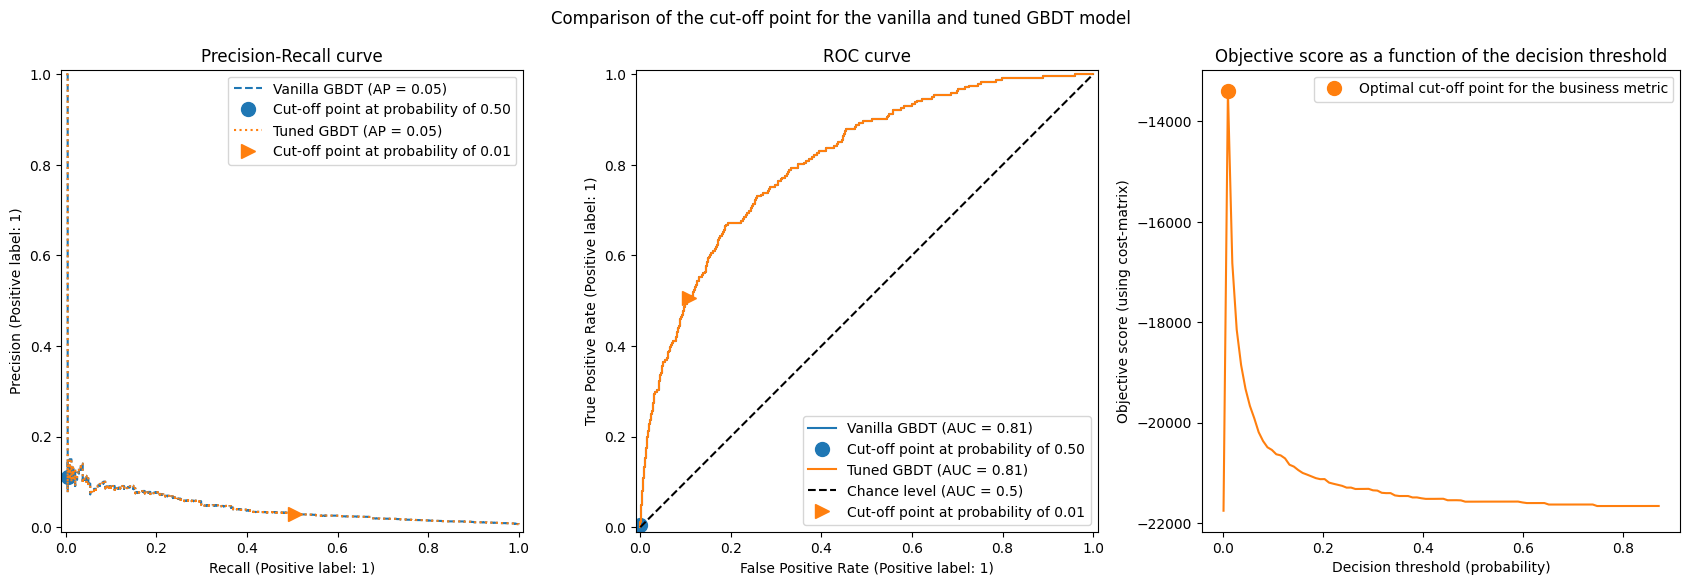

In [49]:
def plot_roc_pr_curves(model, tuned_model, *, title):
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(21, 6))

    linestyles = ("dashed", "dotted")
    markerstyles = ("o", ">")
    colors = ("tab:blue", "tab:orange")
    names = ("Vanilla GBDT", "Tuned GBDT")
    for idx, (est, linestyle, marker, color, name) in enumerate(zip((model, tuned_model), linestyles, markerstyles, colors, names)):
        decision_threshold = getattr(est, "best_threshold_", 0.5)
        PrecisionRecallDisplay.from_estimator(est, X_test, y_test, linestyle=linestyle,color=color,ax=axs[0],name=name,)
        axs[0].plot(scoring["recall"](est, X_test, y_test),scoring["precision"](est, X_test, y_test),marker,
                    markersize=10,color=color,label=f"Cut-off point at probability of {decision_threshold:.2f}",)

        RocCurveDisplay.from_estimator(est,X_test,y_test,ax=axs[1],name=name,plot_chance_level=idx == 1,)
        axs[1].plot(scoring["fpr"](est, X_test, y_test),scoring["tpr"](est, X_test, y_test),marker,
                    markersize=10,color=color,label=f"Cut-off point at probability of {decision_threshold:.2f}",)

    axs[0].set_title("Precision-Recall curve")
    axs[0].legend()

    axs[1].set_title("ROC curve")
    axs[1].legend()

    axs[2].plot(tuned_model.cv_results_["thresholds"],tuned_model.cv_results_["scores"],color="tab:orange",)
    axs[2].plot(tuned_model.best_threshold_,tuned_model.best_score_,"o",markersize=10,color="tab:orange",label="Optimal cut-off point for the business metric",)

    axs[2].legend()
    axs[2].set_xlabel("Decision threshold (probability)")
    axs[2].set_ylabel("Objective score (using cost-matrix)")
    axs[2].set_title("Objective score as a function of the decision threshold")
    fig.suptitle(title)

title = "Comparison of the cut-off point for the vanilla and tuned GBDT model"
plot_roc_pr_curves(model, tuned_model, title=title)

* Precision-Recall (PR) curve illustrates the trade-off between precision and recall across different probability thresholds. In highly imbalanced classification problems, PR curves are often more informative than ROC curves because they focus on the model's ability to correctly identify the minority class. Our results show that both the baseline and the tuned models follow the same PR curve because threshold tuning does not change the predicted probabilities themselves, but only the decision boundary used to classify observations.

The markers on the PR curve represent the operating points corresponding to two thresholds: the default threshold of 0.5 and the optimized threshold of approximately 0.01. At the default threshold, the model produces very few positive predictions, resulting in relatively higher precision but extremely low recall. This means that most fraudulent cases remain undetected. When the optimized threshold is applied, the operating point moves toward a region with substantially higher recall, indicating that the model identifies a much larger share of potential fraud cases, but at the cost of lower precision.

* The ROC curve shows the relationship between the true positive rate (recall) and the false positive rate across all thresholds. Both the baseline and tuned models achieve the same ROC-AUC value of approximately 0.81, which has to indicate good overall discriminative ability (in fact not really). Similar to the PR curve, the ROC curve itself remains unchanged after threshold tuning because the ranking of predicted probabilities does not change. However, the selected operating point shifts significantly. The default threshold corresponds to a point near the origin of the ROC space, reflecting very low sensitivity. In contrast, the optimized threshold moves the operating point upward along the curve, substantially increasing the true positive rate while accepting a higher false positive rate.

* The third plot shows the objective score as a function of the decision threshold, where the objective is defined using the cost matrix introduced earlier. The curve illustrates how the expected business outcome changes as the threshold varies. The optimal point occurs at a threshold of approximately 0.01, where the objective score reaches its maximum value. This result reflects the asymmetric cost structure of the problem, where false negatives carry a much larger penalty than false positives. As a result, the optimal strategy is to classify observations as positive at much lower probability levels than the conventional 0.5 threshold.

#### Confusion matrices

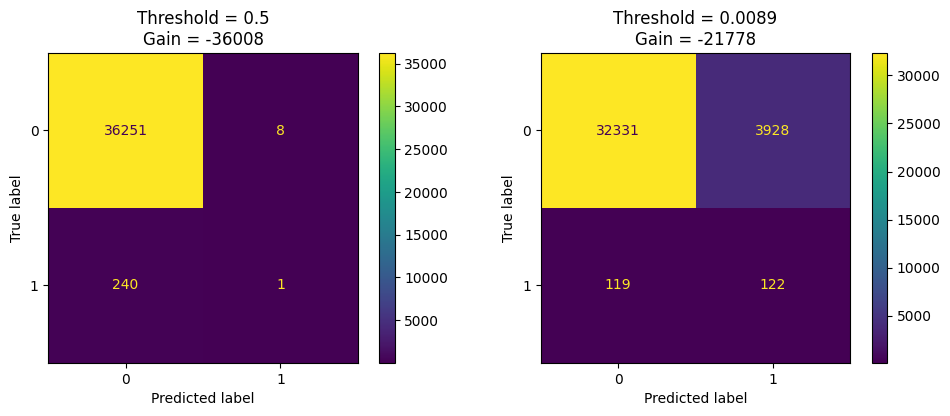

In [50]:
# predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# predictions at default threshold
y_pred_default = (y_proba >= 0.5).astype(int)

# predictions at optimized threshold
best_threshold = tuned_model.best_threshold_
y_pred_tuned = (y_proba >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_default,ax=axes[0],)
axes[0].set_title("Confusion Matrix (Threshold = 0.5)")

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_tuned,ax=axes[1],)
axes[1].set_title(f"Confusion Matrix (Threshold = {best_threshold:.4f})")

gain_default = credit_gain_score(y_test, y_pred_default)
gain_tuned = credit_gain_score(y_test, y_pred_tuned)

axes[0].set_title(f"Threshold = 0.5\nGain = {gain_default}")
axes[1].set_title(f"Threshold = {best_threshold:.4f}\nGain = {gain_tuned}")

plt.tight_layout()
plt.show()

To better understand the impact of threshold tuning, we compare two confusion matrices: one obtained using the default threshold of 0.5, and another using the optimized threshold of 0.0089. At the default threshold, the model tends to produce almost no positive predictions, which results in classifiing almost all instances to the majority class. In contrast, when the optimized threshold is applied, the model becomes more sensitive to potential fraud cases, increasing the number of detected positives. While this adjustment typically leads to a significantly higher number of false positives, it  slightly reduces the number of false negatives and therefore improves the overall business objective defined by the gain matrix.

From all the experiments the main practical insight is that model performance should not be evaluated solely based on standard metrics such as accuracy, f1 or ROC-AUC. Instead, the decision threshold should be aligned with the economic or operational costs associated with different prediction errors. By incorporating these costs into the threshold optimization process, the resulting model can be better adapted to the specific needs of the application

## Conclusion <a name="conclusion"></a>

Now we can make some overall conclusions, some of which may be already known:
1. Some evaluation metrics are deceptive and misleading, and there is no one perfect solution. A model predicting "non-fraud" for every case would achieve 99.34% accuracy while catching zero fraud. Critical evaluation requires metrics like F1-score, Precision-Recall curves, or Brier scores to assess the quality of probability estimates rather than just binary classification.
2. Default classification thresholds fail in imbalanced settings: in the initial "naive" experiments, all models (Logistic Regression, Decision Tree, and HistGradientBoosting) using the default 0.5 probability threshold failed to identify the minority fraud class, often resulting in a Recall of 0.00. This confirms that standard loss functions are biased toward the majority class to minimize global error, making "out-of-the-box" models functionally useless for fraud detection without intervention.
3. Ensemble methods outperform Linear regression and simple Decision tree models (not a big surprise).
4. HistGradientBoostingClassifier (HGBC) showed better results on raw accounting items than on pre-calculated financial ratios.
5. Resampling techniques like SMOTE can be counterproductive because they distort the underlying probability distribution and destroy model calibration. In contrast, post-tuning the decision threshold (e.g., lowering it to ~0.01) significantly improved Recall and business value (Credit Gain) while preserving the integrity of predicted probabilities.
6. The target variable "misstate" is a proxy for the discovery of fraud, not the occurrence of fraud. Because the labels are based on SEC enforcement actions (AAERs), they are skewed toward larger, prominent firms. Exploratory Data Analysis confirms this bias; fraudulent firms in the dataset have mean assets (at) more than double those of non-fraudulent firms (5,567 vs. 2,352). Consequently, models may be learning regulatory priorities rather than universal patterns of corporate dishonesty.
7. The experiments show that the "best" model depends entirely on the stakeholder's cost of errors. By implementing a cost matrix that penalized False Negatives (missing fraud) 150 times more than False Positives, the researchers were able to optimize the threshold to reduce business-defined losses from -36K to -21K.
8. Random Train/Test splits risk data leakage. The sources critically acknowledge that the random division of company-year observations may lead to overly optimistic results. Without a time-aware split (training on past data and testing on future data), the model may exploit "future" information or time-specific correlations that do not generalize to real-world ex-ante prediction. (more in [Discussion](#discussion1) section)
9. Serial fraud requires firm-level isolation. Treating each company-year as an independent sample is a methodological weakness. Serial fraud cases (the same company misstating for several years) create interdependencies; if one year is in the training set and the next in the test set, the model might simply recognize the firm rather than detecting a generalizable fraud signal (more in  [Discussion](#discussion2) section)
10. Computational intractability of high-dimensional SVMs. While theoretically powerful, the Support Vector Classifier (SVC) was excluded from advanced experiments due to its quadratic scaling complexity. For datasets with over 146,000 observations, the computational time required for SVC was "prohibitively time-consuming," reinforcing the need for scalable algorithms like HGBC in large-scale financial auditing.

Overall, predicting accounting fraud from financial statements remains one of the most significant challenges in computational accounting. A general conclusion drawn from the research is that while machine learning offers improvements over traditional methods, it is not a "silver bullet." The effectiveness of these models is constrained by data quality, regulatory biases, and the inherent difficulty of the task.
1. Most Instruments are not robust or efficient. Standard "out-of-the-box" classification tools are functionally useless for fraud detection due to the extreme class imbalance (0.6% fraud rate). In the conducted experiments, naive models with default settings predicted "non-fraud" for every case. Even after sophisticated tuning and cross-validation, the F1-scores remained extremely low (ranging from 0.02 to 0.07), suggesting that the instruments are still quite noisy and generate a high volume of false alarms. (more in [Discussion](#discussion3) section)
2. Model value depends entirely on the final user. There is no single "best" model; suitability is defined by the stakeholder's specific goals and cost structures. The research demonstrated that by adjusting the decision threshold based on a cost matrix (e.g., penalizing a missed fraud 150 times more than a false alarm), a model's business value can be significantly improved, even if its statistical "accuracy" remains low.
3. Misstatement data is insufficient. The core problem in fraud detection is often not the "ratio" of imbalance, but the insufficient absolute number of minority samples. With only 964 fraud cases out of over 146,000 observations, the models have very little information to learn from. This sample size problem means that algorithms may fail to find generalizable patterns and instead overfit to unique noise or specific company identities.
4. Discovery bias that means that data represents SEC interest, but not ground truth for fraud statements. The SEC focuses on larger, prominent firms that pose a systemic risk to market integrity. The models may not be learning what fraud looks like universally, but rather what fraud looks like in large-cap companies that the SEC chooses to investigate.
5.From a research standpoint, fraud classification remains an open question. Fraudulent firms often look remarkably similar to legitimate firms experiencing high volatility or distress, making them non-linearly separable.

## Discussion <a name="discussion"></a>

There are two important methodological questions that were not explicitly addressed in the experiments, which may have significant impact on the results and should be considered in future research.


#### Time-aware train/test split and testing on future data <a name="discussion1"></a>

In this notebook, the train/test split was performed without explicitly enforcing a chronological (time-based) separation between training and test samples. In other words, company-year observations were randomly divided into training and test subsets.

Several studies emphasize the importance of time-aware splits, arguing that random splitting in panel or time-series-like data may lead to data leakage (if information from the future indirectly influences the training process). When data from later years appear in the training set and earlier years in the test set (or vice versa), the model may learn patterns that would not have been available in a true real-world deployment scenario. As a result, performance metrics may be overly optimistic. At the same time, one could argue that the objective of the model is to uncover patterns of fraud that existed historically and use them to detect misstatements in previously issued reports. From this perspective, strict temporal separation may not always be necessary, especially if the goal is retrospective analysis rather than forward-looking prediction.

However, if the intended application is ex-ante detection (predicting misstatements in future filings), then evaluating the model on future data is essential. Without this, we cannot reliably assess how the model would generalize to new regulatory regimes, changing economic conditions, or evolving fraud schemes.

Potential influence on the results:
- Random splits may inflate performance metrics.
- The model may exploit time-specific correlations that do not generalize.
- Tree-based models are especially sensitive to such leakage because they can capture complex interactions, including implicit time signals.

To address this issue in future work:
- Model training on earlier years and testing on later years (e.g., train on 2000–2015, test on 2016–2018).
- Simulation of the realistic deployment by repeatedly training on past data and testing on the next period.
- Blocked cross-validation that respects temporal ordering.


#### Dealing with serial fraud cases <a name="discussion2"></a>

Another important issue concerns so-called 'serial fraud' cases, where the same company reports fraudulent or misstated financial statements in multiple consecutive years. In this notebook, each company-year observation was treated as an independent sample, without explicitly accounting for firm-level dependence or repeated fraud events. However, serial fraud cases introduce strong interdependencies. If a company committed fraud in year t, it may be significantly more likely to do so in year t+1. Financial ratios and other features may remain structurally similar across consecutive years. The model may effectively learn to recognize the company rather than detect fraud-specific patterns. If observations from the same firm appear in both training and test sets, the model may benefit from indirect firm-level information. For example, if year 1 of a fraudulent sequence is in the training set and year 2 is in the test set, the model may detect persistent firm-specific characteristics rather than generalizable fraud indicators.

Potential influence on the results:
- Performance metrics may be inflated.
- The model may overfit to firm-level patterns instead of learning broader fraud signals.
- Reported improvements from imbalance handling techniques (SMOTE) may partially reflect repeated firm patterns rather than genuine generalization.

To mitigate this issue in future research:
- Perform train/test splits at the firm level, ensuring that all observations from a given company are contained entirely within either the training or test set.
- Evaluation procedures to account for firm-level clustering.
- Compare performance on firms never seen during training or firms seen before but in different years.

Both issues—time-aware splitting and serial fraud dependence—are closely related to the broader question of external validity. While the current experiments provide valuable comparative insights, the absolute values of the evaluation metrics should be interpreted with caution.

#### Proper scoring rules <a name="discussion3"></a>

The debates around proper accuracy scoring rules, i.e. rules that are optimized by a correct model. Frank Harrell suggests the Brier score and log-likelihood-based measures and argues  that AUROC is not proper measure (still is good for describing a single model, but not sensitive enough to use for choosing models or comparing even as few as two models). The common rule in this question is: 'Single number metrics are nice for Kaggle. In real life, you need to solve a business need, and the metric needs to be derived from that".

AUC (Area under ROC) is problematic especially when data is imbalanced (so called highly skewed). With imbalanced data, the AUC still gives you suspicious value around 0.8. However, it is high due to large True Negatives, rather than the large TP (True positive). So when we use AUC to measure the performance of classifier, the problem is the increasing of AUC doesn't really reflect a better classifier. It's the side-effect of too many negative examples. Searching for a good performance metrics is still a open question.

If we need to make a decision or take an action we can apply the loss/utility/cost function to the predicted risk and choose the action that optimizes the expected utility.
